# Perform the clustering tasks

In [485]:
from sklearn.cluster import AgglomerativeClustering
import numpy as np
from scipy.cluster.hierarchy import dendrogram, fcluster, set_link_color_palette

import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram
import seaborn as sns
from matplotlib.colors import ListedColormap


from sklearn.metrics import silhouette_score

def find_best_n_clusters(data, min_clusters=2, max_clusters=10, metric='euclidean', linkage='ward'):
    """
    Finds the optimal number of clusters using the silhouette score.
    
    Parameters:
        data (array-like): Input data for clustering.
        min_clusters (int): Minimum number of clusters to evaluate.
        max_clusters (int): Maximum number of clusters to evaluate.
    
    Returns:
        int: Best number of clusters based on silhouette score.
    """
    best_n = min_clusters
    best_score = -1
    for n in range(min_clusters, data.shape[0] - 2):
        model = AgglomerativeClustering(n_clusters=n, linkage=linkage, metric=metric)
        labels = model.fit_predict(data)
        score = silhouette_score(data, labels)
        if score > best_score:
            best_score = score
            best_n = n
    return best_n


def plot_dendrogram(data,
                    ax,
                    labels,
                    title="Hierarchical Clustering Dendrogram",
                    linkage_="complete",
                    distance_= "euclidean",
                    figsize=(10, 6),
                    leaf_rotation=90,
                    leaf_font_size=10,
                    color_threshold=None,
                    show_leaf_counts=True,
                    annotate_above=0,
                    n_clusters=None,
                    color_labels=False,
                    **kwargs):
    """
    Plots a visually enhanced dendrogram from a hierarchical clustering model with consistent colors for each cluster.
    
    Parameters:
        data (array-like): Input data for clustering.
        ax (matplotlib.axes.Axes): Axis to plot on.
        title (str): Title of the dendrogram plot.
        figsize (tuple): Figure size (width, height).
        leaf_rotation (int): Rotation angle for leaf labels.
        leaf_font_size (int): Font size of leaf labels.
        color_threshold (float): Distance threshold for coloring clusters.
        show_leaf_counts (bool): Whether to display leaf counts.
        annotate_above (float): Threshold above which to annotate the dendrogram.
        n_clusters (int): Number of clusters to extract from the dendrogram.
        **kwargs: Additional arguments passed to `dendrogram`.
    """
    model = AgglomerativeClustering(distance_threshold=0,
                                    n_clusters=None,
                                    metric=distance_,
                                    linkage=linkage_)
    model.fit(data)
    
    n_samples = len(model.labels_)
    counts = np.zeros(model.children_.shape[0])
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # leaf node
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]
    ).astype(float)

    model = AgglomerativeClustering(distance_threshold=color_threshold,
                                    metric=distance_, linkage=linkage_, n_clusters=None)
    model.fit(data)
    
    
    # Compute dendrogram and extract leaf labels
    with plt.rc_context({'lines.linewidth': 3}):
        dendro = dendrogram(
            linkage_matrix,
            leaf_rotation=leaf_rotation,
            leaf_font_size=leaf_font_size,
            color_threshold=color_threshold,
            show_leaf_counts=show_leaf_counts,
            # above_threshold_color='gray',
            above_threshold_color='k',
            ax=ax,
            labels=labels,
            **kwargs
        )
                
        if annotate_above > 0:
            for i, d in enumerate(linkage_matrix[:, 2]):
                if d > annotate_above:
                    ax.annotate(f"{d:.2f}", 
                                (i, d), 
                                xytext=(5, 5), 
                                textcoords="offset points",
                                fontsize=9,
                                color="black")

        best_clusters = find_best_n_clusters(data, min_clusters=2, max_clusters=10, metric=distance_, linkage=linkage_)

        ax.set_title(f"{title}", # \n (Optimum number of clusters: {best_clusters})",
                    fontsize=12,
                    fontweight="semibold")
        ax.set_xlabel("", fontsize=12)
        ax.set_ylabel("Distance", fontsize=12)
        ax.grid(axis="y", linestyle="--", alpha=0.5)

In [486]:
# Load the dataset
import pandas as pd


with open("dataset/tf_idf.csv") as f:
    frequency_df = pd.read_csv(f)

stylometry_df = pd.read_csv("dataset/stylometry.csv")

## Study all gospels

/Users/sophrobhayek/Documents/dev/auto_q/venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/sophrobhayek/Documents/dev/auto_q/venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


9 [0.62597148 0.43624615]
11 [ 0.91104739 -0.96353483]
9 [-0.60844403 -0.98487425]
11 [0.29494943 0.7960611 ]
9 [-0.51303541  0.85406909]
11 [-0.87946522  0.86887205]
9 [-0.29675463 -0.79715834]
11 [-0.02825648 -0.48644686]
9 [-0.4302542  -0.38542007]
11 [0.6060518  0.07832255]
9 [-0.3773846   0.22066757]
11 [ 0.43230135 -0.454752  ]
9 [-0.1729018  -0.75622781]
11 [-0.6377013   0.36223571]
9 [-0.6371233   0.05032677]
11 [ 0.41809252 -0.78624615]
9 [ 0.13462444 -0.48687443]
11 [ 0.92585375 -0.03290871]
9 [0.6119851  0.10045308]
11 [-0.91317493  0.26630275]
9 [0.90280668 0.20322364]
11 [0.63837772 0.76841293]
9 [-0.54384046 -0.57591032]
11 [ 0.22196198 -0.17794306]
9 [0.67972261 0.80004625]
11 [-0.29315724 -0.52625888]
9 [ 0.56105103 -0.45038793]
11 [ 0.64522864 -0.15252349]
9 [ 0.3350998  -0.80892937]
11 [ 0.24771865 -0.09646464]
9 [ 0.17321693 -0.66397158]
11 [0.47374749 0.72559416]
9 [-0.5665204  -0.80857089]
11 [-0.95272283  0.283943  ]
9 [0.21418807 0.09339483]
11 [-0.53610581 -0.21

/var/folders/7k/nf094zsx3c3fvbzcnlq9dn000000gn/T/ipykernel_18032/4055462457.py:112: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


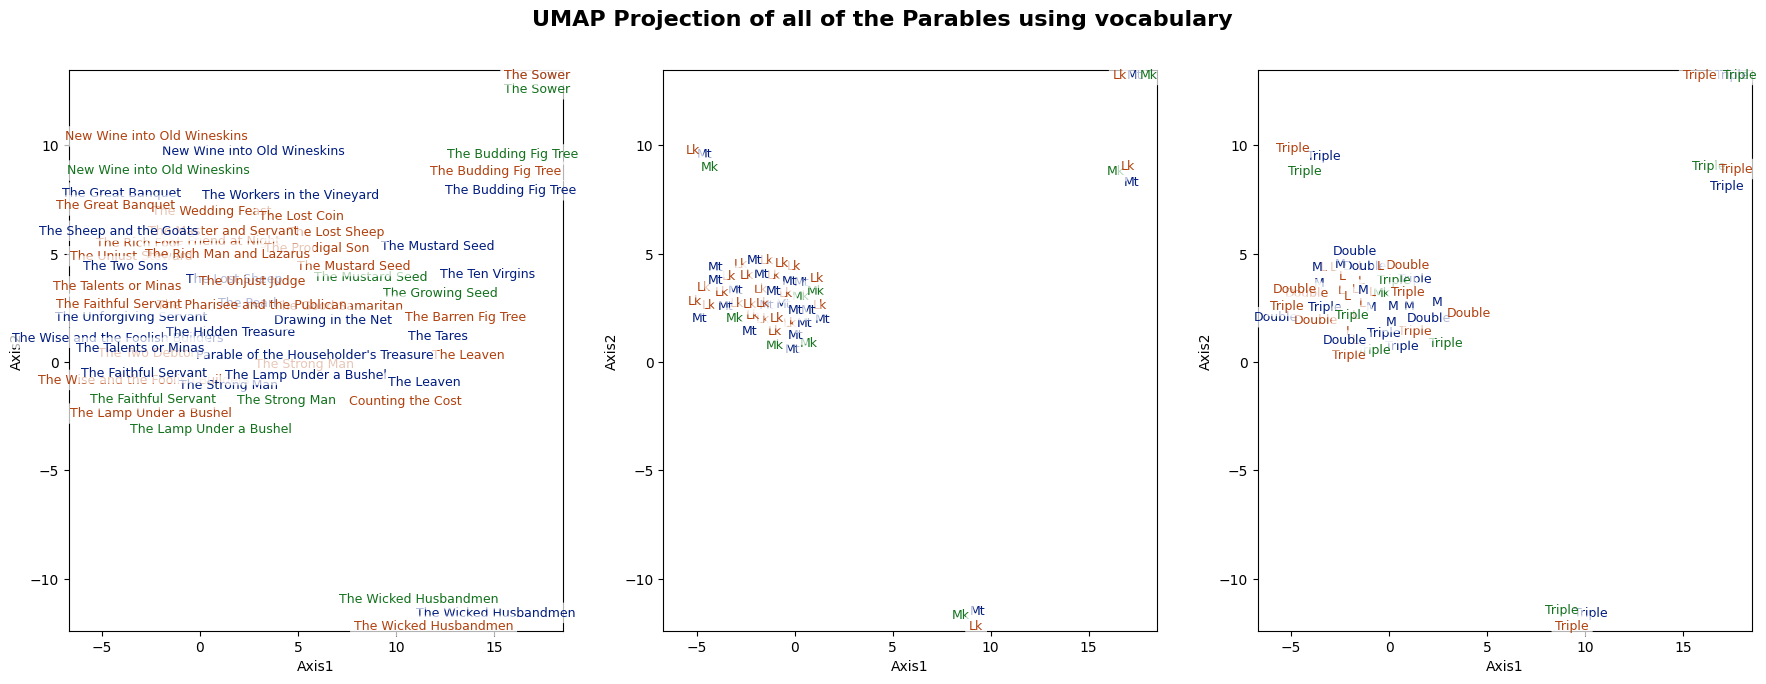

In [487]:
# Perform PCA on the vocabulary matrix
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering
from adjustText import adjust_text
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.spatial import ConvexHull

# Create side-by-side subplots
fig, axes = plt.subplots(1, 3, figsize=(22, 8), constrained_layout=True)  # One row, three columns

# Apply PCA
pca = umap.UMAP(n_components=2, metric="cosine", n_neighbors=3, random_state=42)
all_df = frequency_df



# Apply HAC clustering
selected_number_clusters = find_best_n_clusters(
    all_df.drop(columns=["parable", "book", "source", "source_interpretation"]),
    min_clusters=2,
    max_clusters=20, 
    metric='cosine', 
    linkage='average'
)
hac = AgglomerativeClustering(n_clusters=selected_number_clusters, linkage='average', metric='cosine')
all_df["cluster"] = hac.fit_predict(all_df.drop(columns=["parable", "book", "source", "source_interpretation"]))

unique_labels = all_df["cluster"].unique()
palette = dict(zip(unique_labels, sns.color_palette("dark", len(unique_labels))))
unique_sources = all_df["source"].unique()
source_palette = dict(zip(unique_sources, sns.color_palette("dark", len(unique_sources))))

unique_books = all_df["book"].unique()

book_palette = dict(zip(unique_books, sns.color_palette("dark", len(unique_books))))


# Perform PCA transformation
principal_components = pca.fit_transform(all_df.drop(columns=["parable", "book", "source", "source_interpretation"]))
principal_df = pd.DataFrame(data=principal_components, columns=["Axis1", "Axis2"])
principal_df["parable"] = all_df["parable"].values
principal_df["labels"] = all_df["cluster"].values
principal_df["source"] = all_df["source"].values  # Only used for the second plot
principal_df["book"] = all_df["book"].values  # Only used for the second plot

# Generate a color palette
unique_labels = all_df["cluster"].unique()
palette = dict(zip(unique_labels, sns.color_palette("dark", len(unique_labels))))

# Compute Convex Hull to estimate good label boundaries
hull = ConvexHull(principal_df[["Axis1", "Axis2"]].values)
hull_padding = 1.5

# Adjust axis limits based on the convex hull
x_min, x_max = principal_df["Axis1"].min() - hull_padding, principal_df["Axis1"].max() + hull_padding
y_min, y_max = principal_df["Axis2"].min() - 0.2 * hull_padding, principal_df["Axis2"].max() + 0.2 * hull_padding


# ----------- First plot (labels = parables) -----------
ax = axes[0]
sns.scatterplot(data=principal_df, x="Axis1", y="Axis2", hue="labels", palette=palette, legend=False, alpha=0, ax=ax)
texts = [
    ax.text(principal_df.Axis1[line], principal_df.Axis2[line], principal_df.parable[line],
            color=book_palette[principal_df.book[line]],
            horizontalalignment='left', size=9, bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.3'))
    for line in range(principal_df.shape[0])
]
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
#ax.set_title("PCA - Parables", fontweight='bold')
ax.set_xlabel("Axis1")
ax.set_ylabel("Axis2")
adjust_text(texts, expand_text=(1.5, 1.5), expand_points=(2, 2), force_text=(0.2, 0.8), ax=ax)

# ----------- Second plot (labels = books) -----------
ax = axes[1]
sns.scatterplot(data=principal_df, x="Axis1", y="Axis2", hue="labels", palette=palette, legend=False, alpha=0, ax=ax)
texts = [
    ax.text(principal_df.Axis1[line], principal_df.Axis2[line], principal_df.book[line],
            horizontalalignment='left', size=9, color=book_palette[principal_df.book[line]],
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.3'))
    for line in range(principal_df.shape[0])
]
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
#ax.set_title("PCA - Books", fontweight='bold')
ax.set_xlabel("Axis1")
ax.set_ylabel("Axis2")
adjust_text(texts, expand_text=(1.5, 1.5), expand_points=(2, 2), force_text=(0.2, 0.1), ax=ax)

# ----------- Third plot (labels = sources) -----------
ax = axes[2]
sns.scatterplot(data=principal_df, x="Axis1", y="Axis2", hue="labels", palette=palette, legend=False, alpha=0, ax=ax)
texts = [
    ax.text(principal_df.Axis1[line], principal_df.Axis2[line], principal_df.source[line],
            horizontalalignment='left', size=9, 
                        color=book_palette[principal_df.book[line]],
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.3'))
    for line in range(principal_df.shape[0])
]
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
#ax.set_title("PCA - Sources", fontweight='bold')
ax.set_xlabel("Axis1")
ax.set_ylabel("Axis2")
adjust_text(texts, expand_text=(1.5, 1.5), expand_points=(2, 2), force_text=(0.2, 0.1), ax=ax)

# Save and show the figure
plt.suptitle(f"UMAP Projection of all of the Parables using vocabulary", fontweight='bold', fontsize=16, y=.9)
plt.tight_layout()
plt.savefig("figures/all_vocabulary_pca_three_way.png", dpi=600)
plt.show()


/Users/sophrobhayek/Documents/dev/auto_q/venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/sophrobhayek/Documents/dev/auto_q/venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/var/folders/7k/nf094zsx3c3fvbzcnlq9dn000000gn/T/ipykernel_18032/1269976884.py:115: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


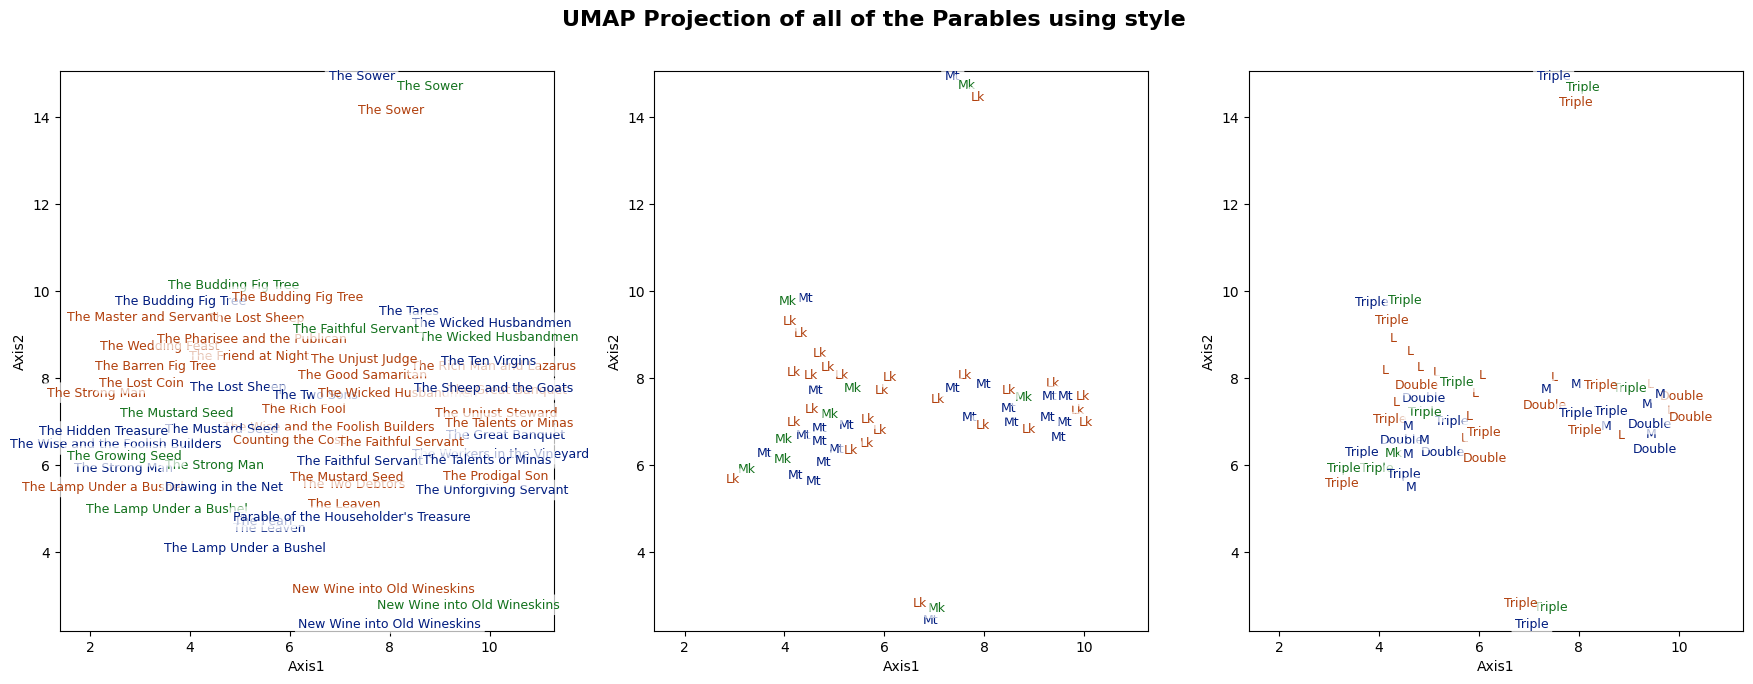

In [488]:
from sklearn.preprocessing import StandardScaler


import umap

scaler = StandardScaler()
# Create side-by-side subplots with three columns
fig, axes = plt.subplots(1, 3, figsize=(22, 8), constrained_layout=True)  # One row, three columns

# Apply PCA
pca = umap.UMAP(n_components=2, metric="manhattan", n_neighbors=4, random_state=42)

all_df = scaler.fit_transform(stylometry_df.drop(columns=["parable", "book", "source", "source_interpretation"]))
all_df = pd.DataFrame(data=all_df, columns=stylometry_df.columns[4:])
all_df["parable"] = frequency_df["parable"].values
all_df["book"] = frequency_df["book"].values
all_df["source"] = frequency_df["source"].values
all_df["source_interpretation"] = frequency_df["source_interpretation"].values

# Apply HAC clustering
selected_number_clusters = find_best_n_clusters(
    all_df.drop(columns=["parable", "book", "source", "source_interpretation"]),
    min_clusters=2,
    max_clusters=20, 
    metric='cosine', 
    linkage='average'
)
hac = AgglomerativeClustering(n_clusters=selected_number_clusters, linkage='average', metric='cosine')
all_df["cluster"] = hac.fit_predict(all_df.drop(columns=["parable", "book", "source", "source_interpretation"]))


unique_labels = all_df["cluster"].unique()
palette = dict(zip(unique_labels, sns.color_palette("dark", len(unique_labels))))
unique_sources = all_df["source"].unique()
source_palette = dict(zip(unique_sources, sns.color_palette("dark", len(unique_sources))))
unique_books = all_df["book"].unique()
book_palette = dict(zip(unique_books, sns.color_palette("dark", len(unique_books))))


# Perform PCA transformation
principal_components = pca.fit_transform(all_df.drop(columns=["parable", "book", "source", "source_interpretation"]))
principal_df = pd.DataFrame(data=principal_components, columns=["Axis1", "Axis2"])
principal_df["parable"] = all_df["parable"].values
principal_df["labels"] = all_df["cluster"].values
principal_df["source"] = all_df["source"].values  # Only used for the second plot
principal_df["book"] = all_df["book"].values  # Only used for the second plot

selected_number_clusters = find_best_n_clusters(
    principal_df.drop(columns=["parable", "book", "source", "labels"]),
    min_clusters=2,
    max_clusters=20, 
    metric='cosine', 
    linkage='average'
)

# Compute Convex Hull to estimate good label boundaries
hull = ConvexHull(principal_df[["Axis1", "Axis2"]].values)
hull_padding = 1.5

# Adjust axis limits based on the convex hull
x_min, x_max = principal_df["Axis1"].min() - hull_padding, principal_df["Axis1"].max() + hull_padding
y_min, y_max = principal_df["Axis2"].min() - 0.2 * hull_padding, principal_df["Axis2"].max() + 0.2 * hull_padding


# ----------- First plot (labels = parables) -----------
ax = axes[0]
sns.scatterplot(data=principal_df, x="Axis1", y="Axis2", hue="labels", palette=palette, legend=False, alpha=0, ax=ax)
texts = [
    ax.text(principal_df.Axis1[line], principal_df.Axis2[line], principal_df.parable[line],
            color=book_palette[principal_df.book[line]],
            horizontalalignment='left', size=9, bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.3'))
    for line in range(principal_df.shape[0])
]
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
#ax.set_title("PCA - Parables", fontweight='bold')
ax.set_xlabel("Axis1")
ax.set_ylabel("Axis2")
adjust_text(texts, expand_text=(1.5, 1.5), expand_points=(2, 2), force_text=(0.2, 0.8), ax=ax)

# ----------- Second plot (labels = books) -----------
ax = axes[1]
sns.scatterplot(data=principal_df, x="Axis1", y="Axis2", hue="labels", palette=palette, legend=False, alpha=0, ax=ax)
texts = [
    ax.text(principal_df.Axis1[line], principal_df.Axis2[line], principal_df.book[line],
            horizontalalignment='left', size=9, color=book_palette[principal_df.book[line]],
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.3'))
    for line in range(principal_df.shape[0])
]
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
#ax.set_title("PCA - Books", fontweight='bold')
ax.set_xlabel("Axis1")
ax.set_ylabel("Axis2")
adjust_text(texts, expand_text=(1.5, 1.5), expand_points=(2, 2), force_text=(0.2, 0.1), ax=ax)

# ----------- Third plot (labels = sources) -----------
ax = axes[2]
sns.scatterplot(data=principal_df, x="Axis1", y="Axis2", hue="labels", palette=palette, legend=False, alpha=0, ax=ax)
texts = [
    ax.text(principal_df.Axis1[line], principal_df.Axis2[line], principal_df.source[line],
            horizontalalignment='left', size=9, color=book_palette[principal_df.book[line]],
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.3'))
    for line in range(principal_df.shape[0])
]
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
#ax.set_title("PCA - Sources", fontweight='bold')
ax.set_xlabel("Axis1")
ax.set_ylabel("Axis2")
adjust_text(texts, expand_text=(1.5, 1.5), expand_points=(2, 2), force_text=(0.2, 0.1), ax=ax)

# Save and show the figure
plt.suptitle(f"UMAP Projection of all of the Parables using style", fontweight='bold', fontsize=16, y=.9)
plt.tight_layout()
plt.savefig("figures/all_style_pca_three_way.png", dpi=600)
plt.show()

/Users/sophrobhayek/Documents/dev/auto_q/venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/sophrobhayek/Documents/dev/auto_q/venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/sophrobhayek/Documents/dev/auto_q/venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/sophrobhayek/Documents/dev/auto_q/venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


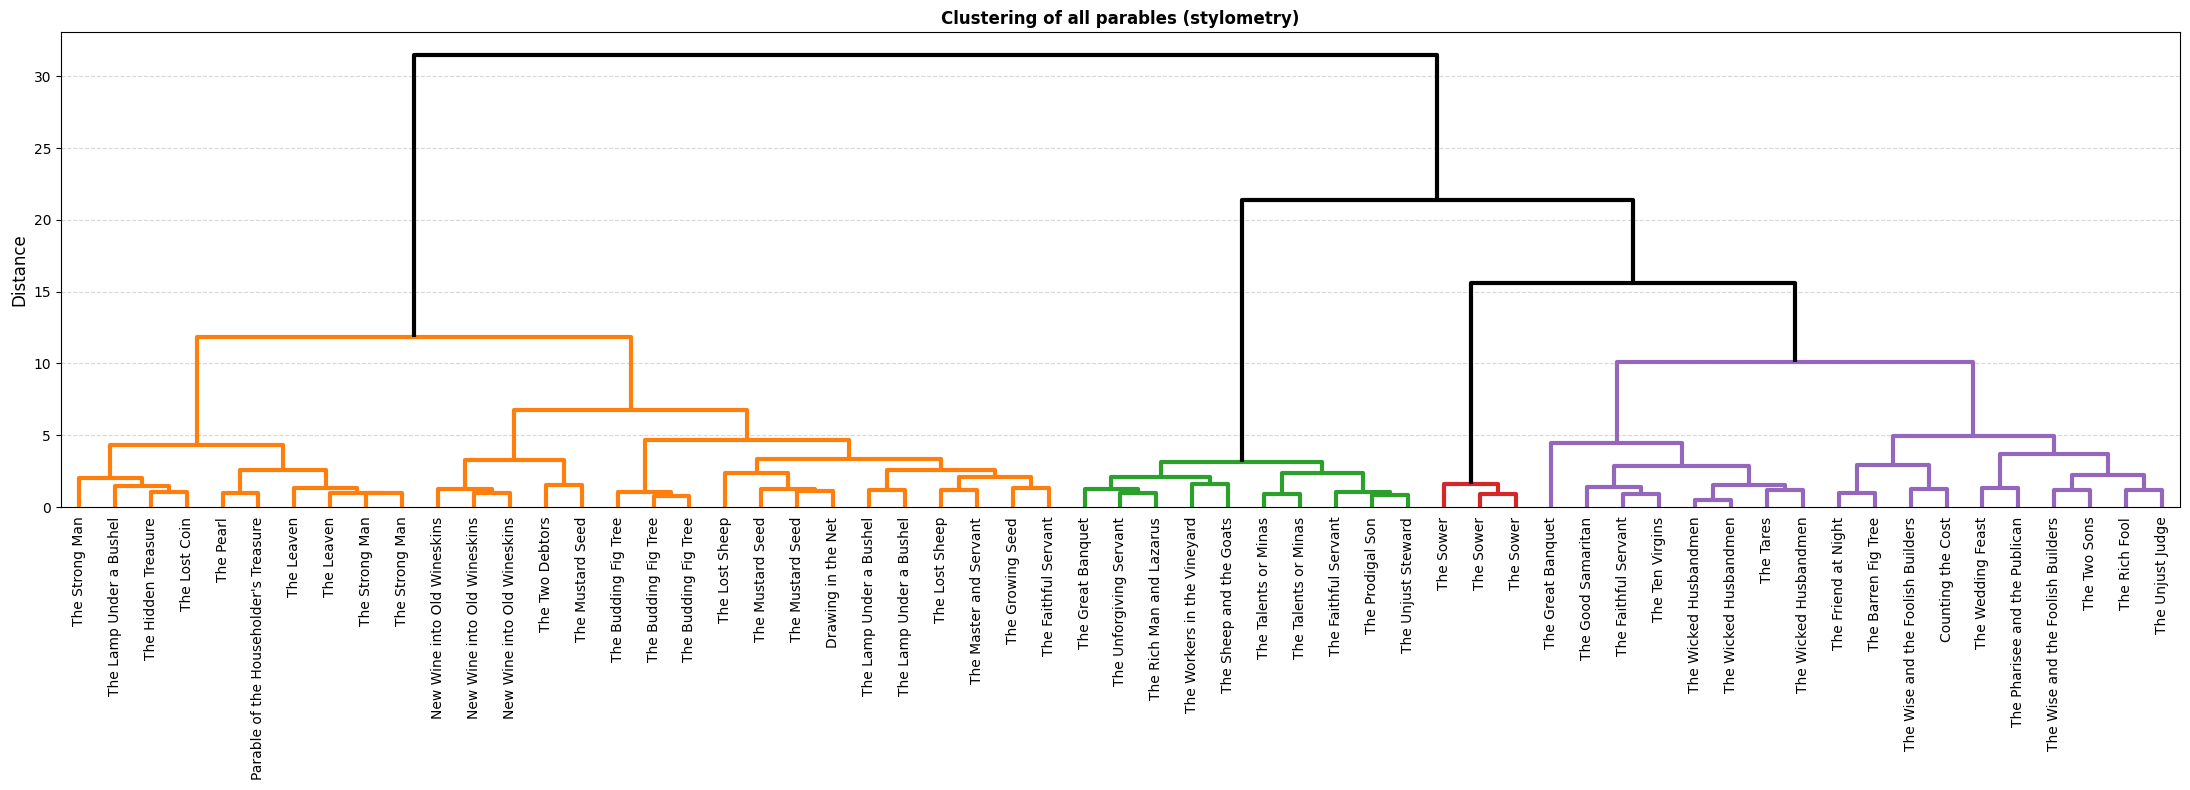

In [489]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
import umap  # Assuming umap is used in the plot_dendrogram function

# Set up the figure with a 2x1 layout for the right pane
fig, axes = plt.subplots(1, 1, figsize=(22, 8)) # Adjusted figsize for better vertical display

# ---------------- Compute PCA for both datasets ----------------
pca_vocab = umap.UMAP(n_components=15, metric="manhattan", n_neighbors=5, random_state=42)  # Use 15 principal components
principal_vocabulary = pca_vocab.fit_transform(frequency_df.drop(columns=["parable", "book", "source", "source_interpretation"]))

pca_style = umap.UMAP(n_components=15, metric="manhattan", n_neighbors=5, random_state=42)  # Use 15 principal components
principal_stylometry = pca_style.fit_transform(stylometry_df.drop(columns=["parable", "book", "source", "source_interpretation"]))

# ---------------- Second dendrogram (Stylometry - Parables) ----------------
plot_dendrogram(
    principal_stylometry,  # PCA-transformed data
    axes,  # First row
    labels=stylometry_df.parable.values,
    title="Clustering of all parables (stylometry)",
    linkage_="complete",
    distance_="manhattan",
    leaf_rotation=90,
    leaf_font_size=10,
    color_threshold=12,
    show_leaf_counts=True,
    annotate_above=0,
    n_clusters=None,
    color_labels=True
)

# ---------------- Fourth dendrogram (Stylometry - Source) ----------------
# plot_dendrogram(
#     principal_stylometry,  # PCA-transformed data
#     axes[1],  # Second row
#     labels=stylometry_df.source.values,  # Use book names instead of parables
#     title="Stylometry (Source)",
#     linkage_="complete",
#     distance_="manhattan",
#     leaf_rotation=90,
#     leaf_font_size=10,
#     color_threshold=12,
#     show_leaf_counts=True,
#     annotate_above=0,
#     n_clusters=None,
#     color_labels=True
# )

# Adjust layout and add a super title
plt.tight_layout()
#plt.suptitle("Cluster Analysis of All Parables", fontweight='bold', fontsize=16, y=1.05)


plt.savefig("figures/all_dendrograms.png", dpi=600)

plt.show()

In [490]:
from sklearn.cluster import AgglomerativeClustering

pca_style = umap.UMAP(n_components=15, metric="manhattan", n_neighbors=5, random_state=42)  # Use 15 principal components
principal_stylometry = pca_style.fit_transform(stylometry_df.drop(columns=["parable", "book", "source", "source_interpretation"]))

hac = AgglomerativeClustering(n_clusters=4)

hac.fit(principal_stylometry)

principal_stylometry = pd.DataFrame(principal_stylometry)
principal_stylometry["source"] = stylometry_df.source
principal_stylometry["cluster"] = hac.labels_

print((principal_stylometry.groupby(["cluster", "source"]).count()/principal_stylometry.groupby(["cluster"]).count()[0]*100)[0].to_latex())

\begin{tabular}{llr}
\toprule
 &  & 0 \\
cluster & source &  \\
\midrule
\multirow[t]{5}{*}{0} & Double & 9.523810 \\
 & L & 9.523810 \\
 & M & 4.761905 \\
 & Mk & 4.761905 \\
 & Triple & 71.428571 \\
\cline{1-3}
\multirow[t]{4}{*}{1} & Double & 14.285714 \\
 & L & 38.095238 \\
 & M & 14.285714 \\
 & Triple & 19.047619 \\
\cline{1-3}
\multirow[t]{4}{*}{2} & Double & 14.285714 \\
 & L & 14.285714 \\
 & M & 14.285714 \\
 & Triple & 4.761905 \\
\cline{1-3}
\multirow[t]{4}{*}{3} & Double & 9.523810 \\
 & L & 4.761905 \\
 & M & 14.285714 \\
 & Triple & 19.047619 \\
\cline{1-3}
\bottomrule
\end{tabular}



/Users/sophrobhayek/Documents/dev/auto_q/venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/sophrobhayek/Documents/dev/auto_q/venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [491]:
principal_stylometry.groupby(["cluster"]).count()[0].values


array([21, 18, 10, 10])

## Study on the triple tradition

### Vocabulary

/var/folders/7k/nf094zsx3c3fvbzcnlq9dn000000gn/T/ipykernel_18032/1129843709.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  all_df["cluster"] = hac.fit_predict(all_df.drop(columns=["parable", "book", "source", "source_interpretation"]))
/Users/sophrobhayek/Documents/dev/auto_q/venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/var/folders/7k/nf094zsx3c3fvbzcnlq9dn000000gn/T/ipykernel_18032/1129843709.py:111: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


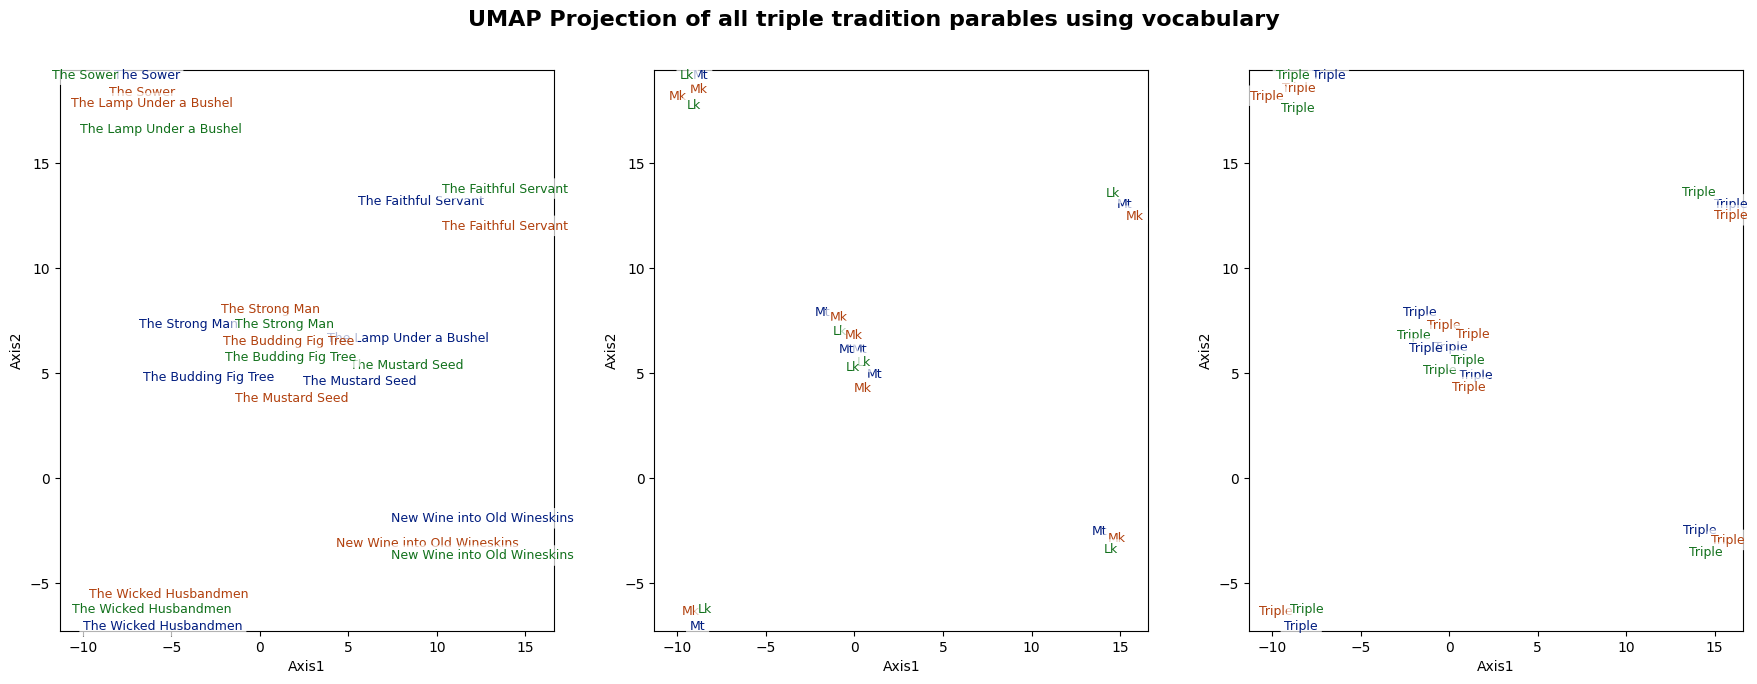

In [492]:
# Perform PCA on the vocabulary matrix
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering
from adjustText import adjust_text
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.spatial import ConvexHull
from sklearn.manifold import TSNE

# Create side-by-side subplots
fig, axes = plt.subplots(1, 3, figsize=(22, 8), constrained_layout=True)  # One row, three columns

# Apply PCA
pca = umap.UMAP(n_components=2, n_neighbors=3, min_dist=0.1, metric="cosine")
all_df = frequency_df[frequency_df["source"] == "Triple"]



# Apply HAC clustering
selected_number_clusters = find_best_n_clusters(
    all_df.drop(columns=["parable", "book", "source", "source_interpretation"]),
    min_clusters=2,
    max_clusters=20, 
    metric='cosine', 
    linkage='average'
)
hac = AgglomerativeClustering(n_clusters=selected_number_clusters, linkage='average', metric='cosine')
all_df["cluster"] = hac.fit_predict(all_df.drop(columns=["parable", "book", "source", "source_interpretation"]))

unique_labels = all_df["cluster"].unique()
palette = dict(zip(unique_labels, sns.color_palette("dark", len(unique_labels))))
unique_sources = all_df["source"].unique()
source_palette = dict(zip(unique_sources, sns.color_palette("dark", len(unique_sources))))
unique_books = all_df["book"].unique()
book_palette = dict(zip(unique_books, sns.color_palette("dark", len(unique_books))))


# Perform PCA transformation
principal_components = pca.fit_transform(all_df.drop(columns=["parable", "book", "source", "source_interpretation"]))
principal_df = pd.DataFrame(data=principal_components, columns=["Axis1", "Axis2"])
principal_df["parable"] = all_df["parable"].values
principal_df["labels"] = all_df["cluster"].values
principal_df["source"] = all_df["source"].values  # Only used for the second plot
principal_df["book"] = all_df["book"].values  # Only used for the second plot

# Generate a color palette
unique_labels = all_df["cluster"].unique()
palette = dict(zip(unique_labels, sns.color_palette("dark", len(unique_labels))))

# Compute Convex Hull to estimate good label boundaries
hull = ConvexHull(principal_df[["Axis1", "Axis2"]].values)
hull_padding = 1.5

# Adjust axis limits based on the convex hull
x_min, x_max = principal_df["Axis1"].min() - hull_padding, principal_df["Axis1"].max() + hull_padding
y_min, y_max = principal_df["Axis2"].min() - 0.2 * hull_padding, principal_df["Axis2"].max() + 0.2 * hull_padding


# ----------- First plot (labels = parables) -----------
ax = axes[0]
sns.scatterplot(data=principal_df, x="Axis1", y="Axis2", hue="labels", palette=palette, legend=False, alpha=0, ax=ax)
texts = [
    ax.text(principal_df.Axis1[line], principal_df.Axis2[line], principal_df.parable[line],
            color=book_palette[principal_df.book[line]],
            horizontalalignment='left', size=9, bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.3'))
    for line in range(principal_df.shape[0])
]
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
#ax.set_title("PCA - Parables", fontweight='bold')
ax.set_xlabel("Axis1")
ax.set_ylabel("Axis2")
adjust_text(texts, expand_text=(1.5, 1.5), expand_points=(2, 2), force_text=(0.2, 0.8), ax=ax)

# ----------- Second plot (labels = books) -----------
ax = axes[1]
sns.scatterplot(data=principal_df, x="Axis1", y="Axis2", hue="labels", palette=palette, legend=False, alpha=0, ax=ax)
texts = [
    ax.text(principal_df.Axis1[line], principal_df.Axis2[line], principal_df.book[line],
            horizontalalignment='left', size=9, color=book_palette[principal_df.book[line]],
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.3'))
    for line in range(principal_df.shape[0])
]
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
#ax.set_title("PCA - Books", fontweight='bold')
ax.set_xlabel("Axis1")
ax.set_ylabel("Axis2")
adjust_text(texts, expand_text=(1.5, 1.5), expand_points=(2, 2), force_text=(0.2, 0.1), ax=ax)

# ----------- Third plot (labels = sources) -----------
ax = axes[2]
sns.scatterplot(data=principal_df, x="Axis1", y="Axis2", hue="labels", palette=palette, legend=False, alpha=0, ax=ax)
texts = [
    ax.text(principal_df.Axis1[line], principal_df.Axis2[line], principal_df.source[line],
            horizontalalignment='left', size=9, 
                        color=book_palette[principal_df.book[line]],
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.3'))
    for line in range(principal_df.shape[0])
]
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
#ax.set_title("PCA - Sources", fontweight='bold')
ax.set_xlabel("Axis1")
ax.set_ylabel("Axis2")
adjust_text(texts, expand_text=(1.5, 1.5), expand_points=(2, 2), force_text=(0.2, 0.1), ax=ax)

# Save and show the figure
plt.suptitle(f"UMAP Projection of all triple tradition parables using vocabulary", fontweight='bold', fontsize=16, y=.9)
plt.tight_layout()
plt.savefig("figures/all_vocabulary_pca_triple.png", dpi=600)
plt.show()


### Stylometry

/var/folders/7k/nf094zsx3c3fvbzcnlq9dn000000gn/T/ipykernel_18032/116263307.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  all_df["cluster"] = hac.fit_predict(all_df.drop(columns=["parable", "book", "source", "source_interpretation"]))
/Users/sophrobhayek/Documents/dev/auto_q/venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/var/folders/7k/nf094zsx3c3fvbzcnlq9dn000000gn/T/ipykernel_18032/116263307.py:103: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


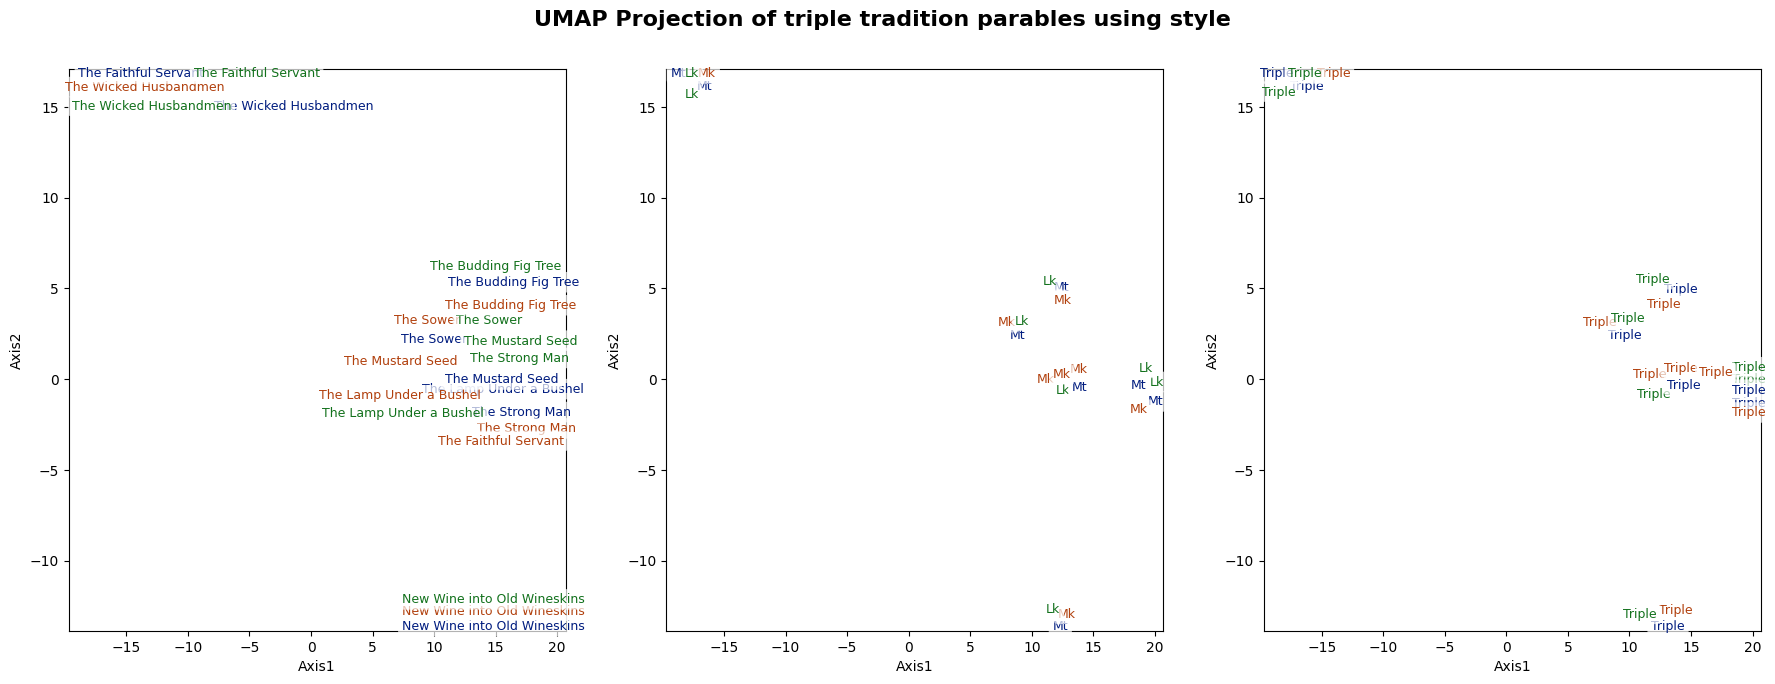

In [493]:
# Create side-by-side subplots with three columns
fig, axes = plt.subplots(1, 3, figsize=(22, 8), constrained_layout=True)  # One row, three columns

# Apply PCA
pca = umap.UMAP(n_components=2, n_neighbors=3, min_dist=0.1, metric="euclidean")
all_df = stylometry_df[stylometry_df["source"] == "Triple"]

# Apply HAC clustering
selected_number_clusters = find_best_n_clusters(
    all_df.drop(columns=["parable", "book", "source", "source_interpretation"]),
    min_clusters=2,
    max_clusters=20, 
    metric='cosine', 
    linkage='average'
)
hac = AgglomerativeClustering(n_clusters=selected_number_clusters, linkage='average', metric='cosine')
all_df["cluster"] = hac.fit_predict(all_df.drop(columns=["parable", "book", "source", "source_interpretation"]))


unique_labels = all_df["cluster"].unique()
palette = dict(zip(unique_labels, sns.color_palette("dark", len(unique_labels))))
unique_sources = all_df["source"].unique()
source_palette = dict(zip(unique_sources, sns.color_palette("dark", len(unique_sources))))
unique_books = all_df["book"].unique()
book_palette = dict(zip(unique_books, sns.color_palette("dark", len(unique_books))))


# Perform PCA transformation
principal_components = pca.fit_transform(all_df.drop(columns=["parable", "book", "source", "source_interpretation"]))
principal_df = pd.DataFrame(data=principal_components, columns=["Axis1", "Axis2"])
principal_df["parable"] = all_df["parable"].values
principal_df["labels"] = all_df["cluster"].values
principal_df["source"] = all_df["source"].values  # Only used for the second plot
principal_df["book"] = all_df["book"].values  # Only used for the second plot

selected_number_clusters = find_best_n_clusters(
    principal_df.drop(columns=["parable", "book", "source", "labels"]),
    min_clusters=2,
    max_clusters=20, 
    metric='cosine', 
    linkage='average'
)

# Compute Convex Hull to estimate good label boundaries
hull = ConvexHull(principal_df[["Axis1", "Axis2"]].values)
hull_padding = 1.5

# Adjust axis limits based on the convex hull
x_min, x_max = principal_df["Axis1"].min() - hull_padding, principal_df["Axis1"].max() + hull_padding
y_min, y_max = principal_df["Axis2"].min() - 0.2 * hull_padding, principal_df["Axis2"].max() + 0.2 * hull_padding


# ----------- First plot (labels = parables) -----------
ax = axes[0]
sns.scatterplot(data=principal_df, x="Axis1", y="Axis2", hue="labels", palette=palette, legend=False, alpha=0, ax=ax)
texts = [
    ax.text(principal_df.Axis1[line], principal_df.Axis2[line], principal_df.parable[line],
            color=book_palette[principal_df.book[line]],
            horizontalalignment='left', size=9, bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.3'))
    for line in range(principal_df.shape[0])
]
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
#ax.set_title("PCA - Parables", fontweight='bold')
ax.set_xlabel("Axis1")
ax.set_ylabel("Axis2")
adjust_text(texts, expand_text=(1.5, 1.5), expand_points=(2, 2), force_text=(0.2, 0.8), ax=ax)

# ----------- Second plot (labels = books) -----------
ax = axes[1]
sns.scatterplot(data=principal_df, x="Axis1", y="Axis2", hue="labels", palette=palette, legend=False, alpha=0, ax=ax)
texts = [
    ax.text(principal_df.Axis1[line], principal_df.Axis2[line], principal_df.book[line],
            horizontalalignment='left', size=9, color=book_palette[principal_df.book[line]],
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.3'))
    for line in range(principal_df.shape[0])
]
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
#ax.set_title("PCA - Books", fontweight='bold')
ax.set_xlabel("Axis1")
ax.set_ylabel("Axis2")
adjust_text(texts, expand_text=(1.5, 1.5), expand_points=(2, 2), force_text=(0.2, 0.1), ax=ax)

# ----------- Third plot (labels = sources) -----------
ax = axes[2]
sns.scatterplot(data=principal_df, x="Axis1", y="Axis2", hue="labels", palette=palette, legend=False, alpha=0, ax=ax)
texts = [
    ax.text(principal_df.Axis1[line], principal_df.Axis2[line], principal_df.source[line],
            horizontalalignment='left', size=9, color=book_palette[principal_df.book[line]],
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.3'))
    for line in range(principal_df.shape[0])
]
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
#ax.set_title("PCA - Sources", fontweight='bold')
ax.set_xlabel("Axis1")
ax.set_ylabel("Axis2")
adjust_text(texts, expand_text=(1.5, 1.5), expand_points=(2, 2), force_text=(0.2, 0.1), ax=ax)

# Save and show the figure
plt.suptitle(f"UMAP Projection of triple tradition parables using style", fontweight='bold', fontsize=16, y=.9)
plt.tight_layout()
plt.savefig("figures/all_style_pca_triple.png", dpi=600)
plt.show()


In [494]:
### Compute the vocabulary and stylistic distance between parables from the triple tradition

# Compute the distance between parabolas of the same name

from sklearn.metrics.pairwise import manhattan_distances, cosine_distances

distances = []

for parable, source in zip(frequency_df.drop_duplicates("parable").parable, frequency_df.drop_duplicates("parable").source):
    if source == "Triple":
        mt = frequency_df[(frequency_df.parable == parable) & (frequency_df.book == "Mt")]
        mk = frequency_df[(frequency_df.parable == parable) & (frequency_df.book == "Mk")]
        lk = frequency_df[(frequency_df.parable == parable) & (frequency_df.book == "Lk")]
        distance_mt_mk = cosine_distances(mt.drop(columns=["parable", "book", "source", "source_interpretation"]), mk.drop(columns=["parable", "book", "source", "source_interpretation"]))[0][0]
        distance_mt_lk = cosine_distances(mt.drop(columns=["parable", "book", "source", "source_interpretation"]), lk.drop(columns=["parable", "book", "source", "source_interpretation"]))[0][0]
        distance_mk_lk = cosine_distances(mk.drop(columns=["parable", "book", "source", "source_interpretation"]), lk.drop(columns=["parable", "book", "source", "source_interpretation"]))[0][0]
        distances.append(
            {
                "parable": parable,
                "tradition": "Triple",
                "type": "vocabulary",
                "distance_mt_mk": distance_mt_mk,
                "distance_mt_lk": distance_mt_lk,
                "distance_mk_lk": distance_mk_lk
            }
        )

for parable, source in zip(stylometry_df.drop_duplicates("parable").parable, stylometry_df.drop_duplicates("parable").source):
    if source == "Triple":
        mt = stylometry_df[(stylometry_df.parable == parable) & (stylometry_df.book == "Mt")]
        mk = stylometry_df[(stylometry_df.parable == parable) & (stylometry_df.book == "Mk")]
        lk = stylometry_df[(stylometry_df.parable == parable) & (stylometry_df.book == "Lk")]
        distance_mt_mk = manhattan_distances(mt.drop(columns=["parable", "book", "source", "source_interpretation"]), mk.drop(columns=["parable", "book", "source", "source_interpretation"]))[0][0]
        distance_mt_lk = manhattan_distances(mt.drop(columns=["parable", "book", "source", "source_interpretation"]), lk.drop(columns=["parable", "book", "source", "source_interpretation"]))[0][0]
        distance_mk_lk = manhattan_distances(mk.drop(columns=["parable", "book", "source", "source_interpretation"]), lk.drop(columns=["parable", "book", "source", "source_interpretation"]))[0][0]
        distances.append(
            {
                "parable": parable,
                "tradition": "Triple",
                "type": "style",
                "distance_mt_mk": distance_mt_mk,
                "distance_mt_lk": distance_mt_lk,
                "distance_mk_lk": distance_mk_lk
            }
        )

In [495]:
pd.DataFrame(distances)

,parable,tradition,type,distance_mt_mk,distance_mt_lk,distance_mk_lk
0,New Wine into Old Wineskins,Triple,vocabulary,0.050439,0.133410,0.108108
1,The Strong Man,Triple,vocabulary,0.012757,0.075871,0.079795
2,The Sower,Triple,vocabulary,0.111665,0.321218,0.341998
3,The Lamp Under a Bushel,Triple,vocabulary,0.268392,0.178719,0.138156
4,The Mustard Seed,Triple,vocabulary,0.026577,0.021905,0.026636
5,The Wicked Husbandmen,Triple,vocabulary,0.136054,0.291417,0.259397
6,The Budding Fig Tree,Triple,vocabulary,0.032163,0.092164,0.109160
7,The Faithful Servant,Triple,vocabulary,0.173756,0.120128,0.295283
8,New Wine into Old Wineskins,Triple,style,160.774073,230.919385,209.693458
9,The Strong Man,Triple,style,46.688199,241.362121,226.770808


In [496]:
distances = pd.DataFrame(distances)
print(distances[distances.type == "style"].drop(["tradition","type"], axis=1).sort_values(["distance_mt_mk"], ascending=False).to_latex(float_format="%.1f", index=False))

\begin{tabular}{lrrr}
\toprule
parable & distance_mt_mk & distance_mt_lk & distance_mk_lk \\
\midrule
The Faithful Servant & 1241.0 & 1275.3 & 2434.4 \\
The Lamp Under a Bushel & 499.3 & 437.8 & 324.9 \\
The Wicked Husbandmen & 403.9 & 475.1 & 358.6 \\
The Sower & 285.5 & 344.8 & 407.9 \\
The Mustard Seed & 237.1 & 233.0 & 339.6 \\
New Wine into Old Wineskins & 160.8 & 230.9 & 209.7 \\
The Budding Fig Tree & 88.2 & 140.9 & 119.7 \\
The Strong Man & 46.7 & 241.4 & 226.8 \\
\bottomrule
\end{tabular}



In [497]:
print(distances[distances.type == "vocabulary"].drop(["tradition","type"], axis=1).sort_values(["distance_mt_mk"], ascending=False).to_latex(float_format="%.2f", index=False))

\begin{tabular}{lrrr}
\toprule
parable & distance_mt_mk & distance_mt_lk & distance_mk_lk \\
\midrule
The Lamp Under a Bushel & 0.27 & 0.18 & 0.14 \\
The Faithful Servant & 0.17 & 0.12 & 0.30 \\
The Wicked Husbandmen & 0.14 & 0.29 & 0.26 \\
The Sower & 0.11 & 0.32 & 0.34 \\
New Wine into Old Wineskins & 0.05 & 0.13 & 0.11 \\
The Budding Fig Tree & 0.03 & 0.09 & 0.11 \\
The Mustard Seed & 0.03 & 0.02 & 0.03 \\
The Strong Man & 0.01 & 0.08 & 0.08 \\
\bottomrule
\end{tabular}



In [498]:
# Study why the distance is so low for the Parable "The Faithful Servant" in the vocabulary of Luke and Matthew, vs Mark

mt = frequency_df[(frequency_df.parable == "The Faithful Servant") & (frequency_df.book == "Mt")]
lk = frequency_df[(frequency_df.parable == "The Faithful Servant") & (frequency_df.book == "Lk")]
mk = frequency_df[(frequency_df.parable == "The Faithful Servant") & (frequency_df.book == "Mk")]


In [499]:
diff_df = (mt.drop(columns=["parable", "book", "source", "source_interpretation"]).values - lk.drop(columns=["parable", "book", "source", "source_interpretation"]).values)
diff_df = pd.DataFrame(diff_df, columns=mt.drop(columns=["parable", "book", "source", "source_interpretation"]).columns)

In [500]:
distances[distances.type == "style"].drop(["tradition","type","parable"], axis=1).median()

distance_mt_mk    261.279527
distance_mt_lk    293.070943
distance_mk_lk    332.283887
dtype: float64

In [501]:
distances[distances.type == "vocabulary"].drop(["tradition","type","parable"], axis=1).median()

distance_mt_mk    0.081052
distance_mt_lk    0.126769
distance_mk_lk    0.123658
dtype: float64

In [502]:
### Compute the vocabulary and stylistic distance between parables from the triple tradition

# Compute the distance between parabolas of the same name

from sklearn.metrics.pairwise import manhattan_distances, cosine_distances

distances = []

for parable, source in zip(frequency_df.drop_duplicates("parable").parable, frequency_df.drop_duplicates("parable").source):
    if source == "Double":
        mt = frequency_df[(frequency_df.parable == parable) & (frequency_df.book == "Mt")]
        lk = frequency_df[(frequency_df.parable == parable) & (frequency_df.book == "Lk")]
        distance_mt_lk = cosine_distances(mt.drop(columns=["parable", "book", "source", "source_interpretation"]), lk.drop(columns=["parable", "book", "source", "source_interpretation"]))[0][0]
        distances.append(
            {
                "parable": parable,
                "tradition": "Triple",
                "type": "vocabulary",
                "distance_mt_lk": distance_mt_lk,
            }
        )

for parable, source in zip(stylometry_df.drop_duplicates("parable").parable, stylometry_df.drop_duplicates("parable").source):
    if source == "Double":
        mt = stylometry_df[(stylometry_df.parable == parable) & (stylometry_df.book == "Mt")]
        lk = stylometry_df[(stylometry_df.parable == parable) & (stylometry_df.book == "Lk")]
        distance_mt_lk = manhattan_distances(mt.drop(columns=["parable", "book", "source", "source_interpretation"]), lk.drop(columns=["parable", "book", "source", "source_interpretation"]))[0][0]
        distances.append(
            {
                "parable": parable,
                "tradition": "Triple",
                "type": "style",
                "distance_mt_lk": distance_mt_lk,
            }
        )

In [503]:
distances = pd.DataFrame(distances)

distances[distances.type == "style"].drop(["tradition","type","parable"], axis=1).median()

distance_mt_lk    489.261032
dtype: float64

In [504]:
distances[distances.type == "vocabulary"].drop(["tradition","type","parable"], axis=1).mean()

distance_mt_lk    0.496939
dtype: float64

### Find the most discriminant features for Mark

In [505]:

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=1000, random_state=42)

X = stylometry_df.drop(columns=["parable", "book", "source", "source_interpretation"])
y = stylometry_df.book.apply(lambda x: 1 if x == "Mk" else 0)

rf.fit(X, y)

importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]


In [506]:
importances = pd.DataFrame(importances, index=X.columns, columns=["importance"])
importances.sort_values("importance", ascending=False).head(20)

,importance
mode_P_I,0.029165
mode_I_P,0.016120
gender_M,0.015238
pos_RR_C,0.014367
case_D,0.012658
unique_word_ratio,0.012512
inflectional_complexity,0.012505
head_dependent_ratio,0.011596
gender_M_M,0.011556
person_3_3,0.011406


## Study Matthew's Gospel

### Vocabulary

/Users/sophrobhayek/Documents/dev/auto_q/venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/sophrobhayek/Documents/dev/auto_q/venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/var/folders/7k/nf094zsx3c3fvbzcnlq9dn000000gn/T/ipykernel_18032/468780154.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mt_df["cluster"] = hac.labels_


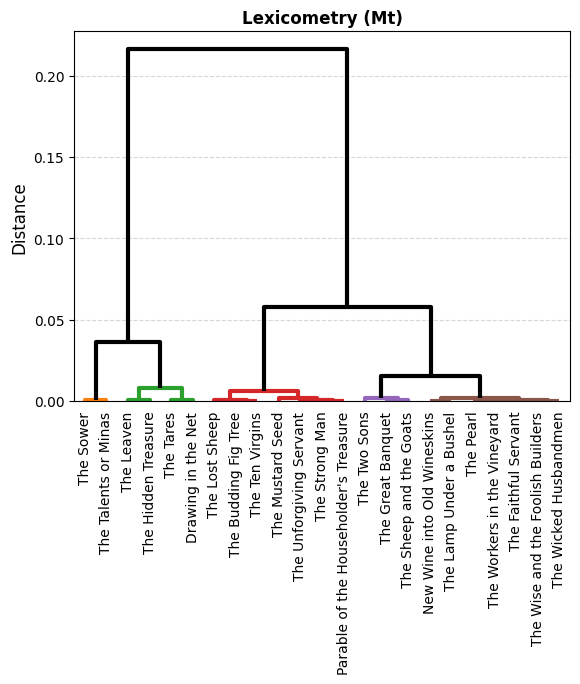

In [507]:
# Mat.Vocab.1 : Apply HAC to the vocabulary dataset of all of Matthew’s parables
mt_df = frequency_df[frequency_df["book"] == "Mt"]
pca = umap.UMAP(n_components=2, metric="cosine", n_neighbors=3, random_state=42)
principal_components = pca.fit_transform(mt_df.drop(columns=["parable", "book", "source", "source_interpretation"]))
principal_df = pd.DataFrame(data=principal_components, columns=["Axis1", "Axis2"])
principal_df["parable"] = mt_df["parable"].values
principal_df["labels"] = mt_df["source"].values
principal_df["source"] = mt_df["source"].values  # Only used for the second plot
principal_df["book"] = mt_df["book"].values  # Only used for the second plot


plot_dendrogram(
    principal_df.drop(columns=["parable", "book", "source", "labels"]),
    plt.gca(),
    #labels=luke_df["parable"].values,
    labels=mt_df.parable.values,
    title="Lexicometry (Mt)",
    linkage_="complete",
    distance_="cosine",
    figsize=(10, 6),
    leaf_rotation=90,
    leaf_font_size=10,
    color_threshold=0.01,
    show_leaf_counts=True,
    annotate_above=0,
    n_clusters=None,
    color_labels=True
)

selected_number_clusters = find_best_n_clusters(mt_df.drop(columns=["parable",
                               "book",
                               "source",
                               "source_interpretation"]), min_clusters=2, max_clusters=20, metric='cosine', linkage='average')

hac = AgglomerativeClustering(n_clusters=selected_number_clusters, linkage='average', metric='cosine')
hac.fit(mt_df.drop(columns=["parable",
                            "book",
                            "source",
                            "source_interpretation"]))
mt_df["cluster"] = hac.labels_

/var/folders/7k/nf094zsx3c3fvbzcnlq9dn000000gn/T/ipykernel_18032/2545260775.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mt_df["cluster"] = hac.fit_predict(mt_df.drop(columns=["parable", "book", "source", "source_interpretation"]))
/Users/sophrobhayek/Documents/dev/auto_q/venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/sophrobhayek/Documents/dev/auto_q/venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/var/folders/7k/nf094zsx3c3fvbzcnlq9dn000000gn/T/ipykernel_18032/2545260775.py:84: Us

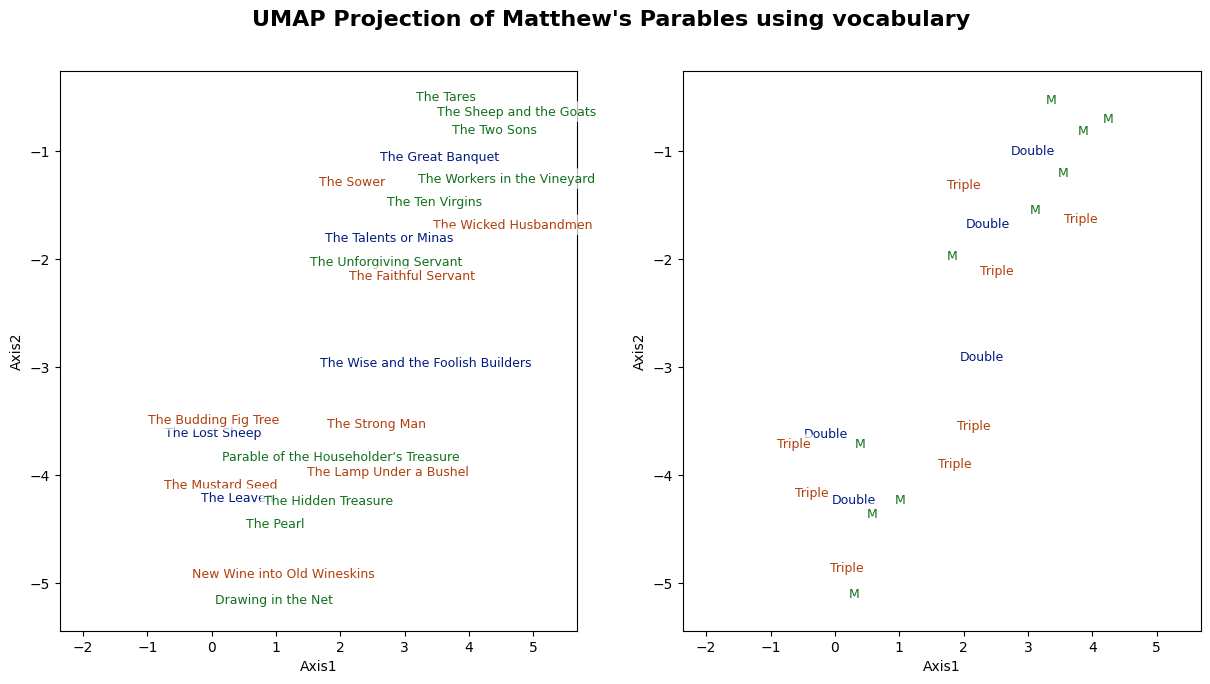

In [508]:
# Perform PCA on the vocabulary matrix
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering
from adjustText import adjust_text
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.spatial import ConvexHull

# Create side-by-side subplots
fig, axes = plt.subplots(1, 2, figsize=(15, 8), constrained_layout=True)  # One row, two columns

# Apply PCA
pca = umap.UMAP(n_components=2, n_neighbors=5, min_dist=0.1, metric="cosine", random_state=40)
mt_df = frequency_df[frequency_df["book"] == "Mt"]

# Apply HAC clustering
selected_number_clusters = find_best_n_clusters(
    mt_df.drop(columns=["parable", "book", "source", "source_interpretation"]),
    min_clusters=2,
    max_clusters=20, 
    metric='cosine', 
    linkage='average'
)
hac = AgglomerativeClustering(n_clusters=selected_number_clusters, linkage='average', metric='cosine')
mt_df["cluster"] = hac.fit_predict(mt_df.drop(columns=["parable", "book", "source", "source_interpretation"]))

# Perform PCA transformation
principal_components = pca.fit_transform(mt_df.drop(columns=["parable", "book", "source", "source_interpretation"]))
principal_df = pd.DataFrame(data=principal_components, columns=["Axis1", "Axis2"])
principal_df["parable"] = mt_df["parable"].values
principal_df["labels"] = mt_df["cluster"].values
principal_df["source"] = mt_df["source"].values  # Only used for the second plot

# Generate a color palette
unique_labels = mt_df["source"].unique()
palette = dict(zip(unique_labels, sns.color_palette("dark", len(unique_labels))))

# Compute Convex Hull to estimate good label boundaries
hull = ConvexHull(principal_df[["Axis1", "Axis2"]].values)
hull_padding = 1.5

# Adjust axis limits based on the convex hull
x_min, x_max = principal_df["Axis1"].min() - hull_padding, principal_df["Axis1"].max() + hull_padding
y_min, y_max = principal_df["Axis2"].min() - 0.2 * hull_padding, principal_df["Axis2"].max() + 0.2 * hull_padding

# ----------- First plot (labels = parables) -----------
ax = axes[0]
# Change alpha to 1 so that points are visible
sns.scatterplot(data=principal_df, x="Axis1", y="Axis2", hue="source", palette=palette, legend=False, alpha=0, ax=ax)
texts = []
for line in range(principal_df.shape[0]):
    texts.append(ax.text(principal_df.Axis1[line], principal_df.Axis2[line],
                         principal_df.parable[line], horizontalalignment='left',
                         size=9, 
                         color=palette[principal_df.source[line]],
                         bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.3')))
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
ax.set_title("", fontweight='bold')
ax.set_xlabel("Axis1")
ax.set_ylabel("Axis2")
adjust_text(texts, expand_text=(1.5, 1.5), expand_points=(2, 2), force_text=(0.2, 0.8), ax=ax)

# ----------- Second plot (labels = sources) -----------
ax = axes[1]
# Change alpha to 1 so that points are visible
p1 = sns.scatterplot(data=principal_df, x="Axis1", y="Axis2", hue="source", palette=palette, legend=False, alpha=0, ax=ax)
texts = []
for line in range(principal_df.shape[0]):
    texts.append(p1.text(principal_df.Axis1[line], principal_df.Axis2[line],
                         principal_df.source[line], horizontalalignment='left',
                         size=9, color=palette[principal_df.source[line]],
                         bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.3')))
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
ax.set_title("", fontweight='bold')
ax.set_xlabel("Axis1")
ax.set_ylabel("Axis2")
adjust_text(texts, expand_text=(1.5, 1.5), expand_points=(2, 2), force_text=(0.2, 0.1))

# Save and show the figure
plt.suptitle(f"UMAP Projection of Matthew's Parables using vocabulary", fontweight='bold', fontsize=16, y=.9)
plt.tight_layout()

plt.savefig("figures/mt_vocabulary_pca_side_by_side.png", dpi=600)

plt.show()



In [509]:
print(mt_df.sort_values(by="cluster")[["cluster", "parable", "source"]].to_latex(index=False))

\begin{tabular}{rll}
\toprule
cluster & parable & source \\
\midrule
0 & Parable of the Householder's Treasure & M \\
0 & The Great Banquet & Double \\
0 & The Ten Virgins & M \\
0 & The Two Sons & M \\
0 & The Workers in the Vineyard & M \\
0 & The Unforgiving Servant & M \\
0 & The Lost Sheep & Double \\
0 & The Talents or Minas & Double \\
0 & Drawing in the Net & M \\
0 & The Pearl & M \\
0 & The Hidden Treasure & M \\
0 & The Leaven & Double \\
0 & The Mustard Seed & Triple \\
0 & The Tares & M \\
0 & The Lamp Under a Bushel & Triple \\
0 & The Sower & Triple \\
0 & The Strong Man & Triple \\
0 & New Wine into Old Wineskins & Triple \\
0 & The Budding Fig Tree & Triple \\
0 & The Faithful Servant & Triple \\
1 & The Sheep and the Goats & M \\
2 & The Wicked Husbandmen & Triple \\
3 & The Wise and the Foolish Builders & Double \\
\bottomrule
\end{tabular}



/Users/sophrobhayek/Documents/dev/auto_q/venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/sophrobhayek/Documents/dev/auto_q/venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


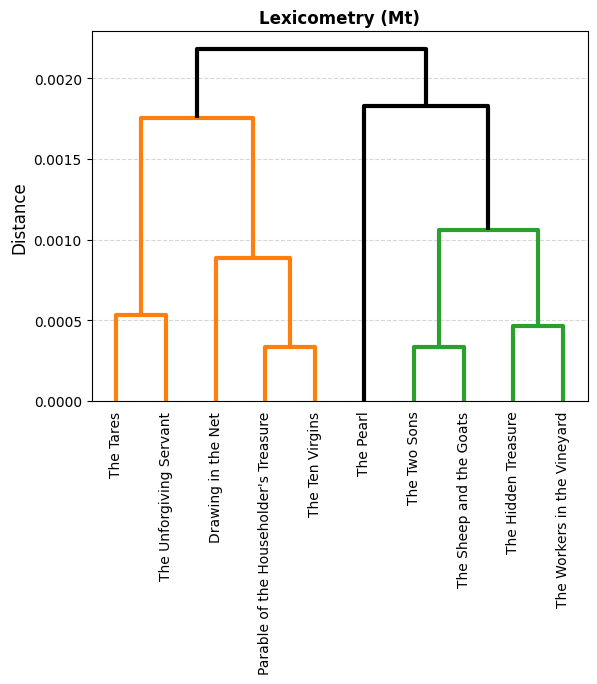

In [510]:
# Mat.Vocab.2: Apply HAC to the vocabulary dataset of Matthew’s parables from M.
pca = umap.UMAP(n_components=5, n_neighbors=3, min_dist=0.1, metric="cosine", random_state=40)

mt_df = frequency_df[(frequency_df["book"] == "Mt") & (frequency_df["source"] == "M")]
mt_df = pca.fit_transform(mt_df.drop(columns=["parable", "book", "source", "source_interpretation"]))
mt_df = pd.DataFrame(data=mt_df, columns=["Axis1", "Axis2", "PC3", "PC4", "PC5"])
mt_df["parable"] = frequency_df[(frequency_df["book"] == "Mt") & (frequency_df["source"] == "M")]["parable"].values
mt_df["book"] = frequency_df[(frequency_df["book"] == "Mt") & (frequency_df["source"] == "M")]["book"].values
mt_df["source"] = frequency_df[(frequency_df["book"] == "Mt") & (frequency_df["source"] == "M")]["source"].values
mt_df["source_interpretation"] = frequency_df[(frequency_df["book"] == "Mt") & (frequency_df["source"] == "M")]["source_interpretation"].values


plot_dendrogram(
    mt_df.drop(columns=["parable",
                               "book",
                               "source",
                               "source_interpretation"]),
    plt.gca(),
    labels=mt_df.parable.values,
    title="Lexicometry (Mt)",
    linkage_="average",
    distance_="cosine",
    figsize=(10, 6),
    leaf_rotation=90,
    leaf_font_size=10,
    color_threshold=0.0018,
    show_leaf_counts=True,
    annotate_above=0,
    n_clusters=None,
    color_labels=True
)

selected_number_clusters = find_best_n_clusters(mt_df.drop(columns=["parable",
                               "book",
                               "source",
                               "source_interpretation"]), min_clusters=2, max_clusters=20, metric='cosine', linkage='average')

hac = AgglomerativeClustering(n_clusters=selected_number_clusters, linkage='average', metric='cosine')
hac.fit(mt_df.drop(columns=["parable",
                            "book",
                            "source",
                            "source_interpretation"]))
mt_df["cluster"] = hac.labels_

In [511]:
print(mt_df.sort_values(by="cluster")[["cluster", "parable", "source_interpretation"]].to_latex(index=False))

\begin{tabular}{rll}
\toprule
cluster & parable & source_interpretation \\
\midrule
0 & The Hidden Treasure & ['M', 'M (Bur)', 'M (Man)'] \\
0 & The Pearl & ['M', 'M (Bur)', 'M (Man)'] \\
0 & The Workers in the Vineyard & ['M', 'M (Bur)', 'M (Man)'] \\
0 & The Two Sons & ['M', 'M (Bur)', 'M (Man)'] \\
0 & The Sheep and the Goats & ['M', 'M (Bur)', 'M (Pan)'] \\
1 & The Tares & ['M', 'M (Bur)', 'M (Man)'] \\
1 & Drawing in the Net & ['M', 'M (Bur)', 'M (Man)'] \\
1 & Parable of the Householder's Treasure & ['M', 'M (Bur)', 'M (Man)'] \\
1 & The Unforgiving Servant & ['M', 'M (Bur, without v. 35)', 'M (Man)'] \\
1 & The Ten Virgins & ['M', 'M (Bur, v. 12 out of M)', 'M (Man)'] \\
\bottomrule
\end{tabular}



### Stylometry study (Matthew)

/Users/sophrobhayek/Documents/dev/auto_q/venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/sophrobhayek/Documents/dev/auto_q/venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/sophrobhayek/Documents/dev/auto_q/venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/sophrobhayek/Documents/dev/auto_q/venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


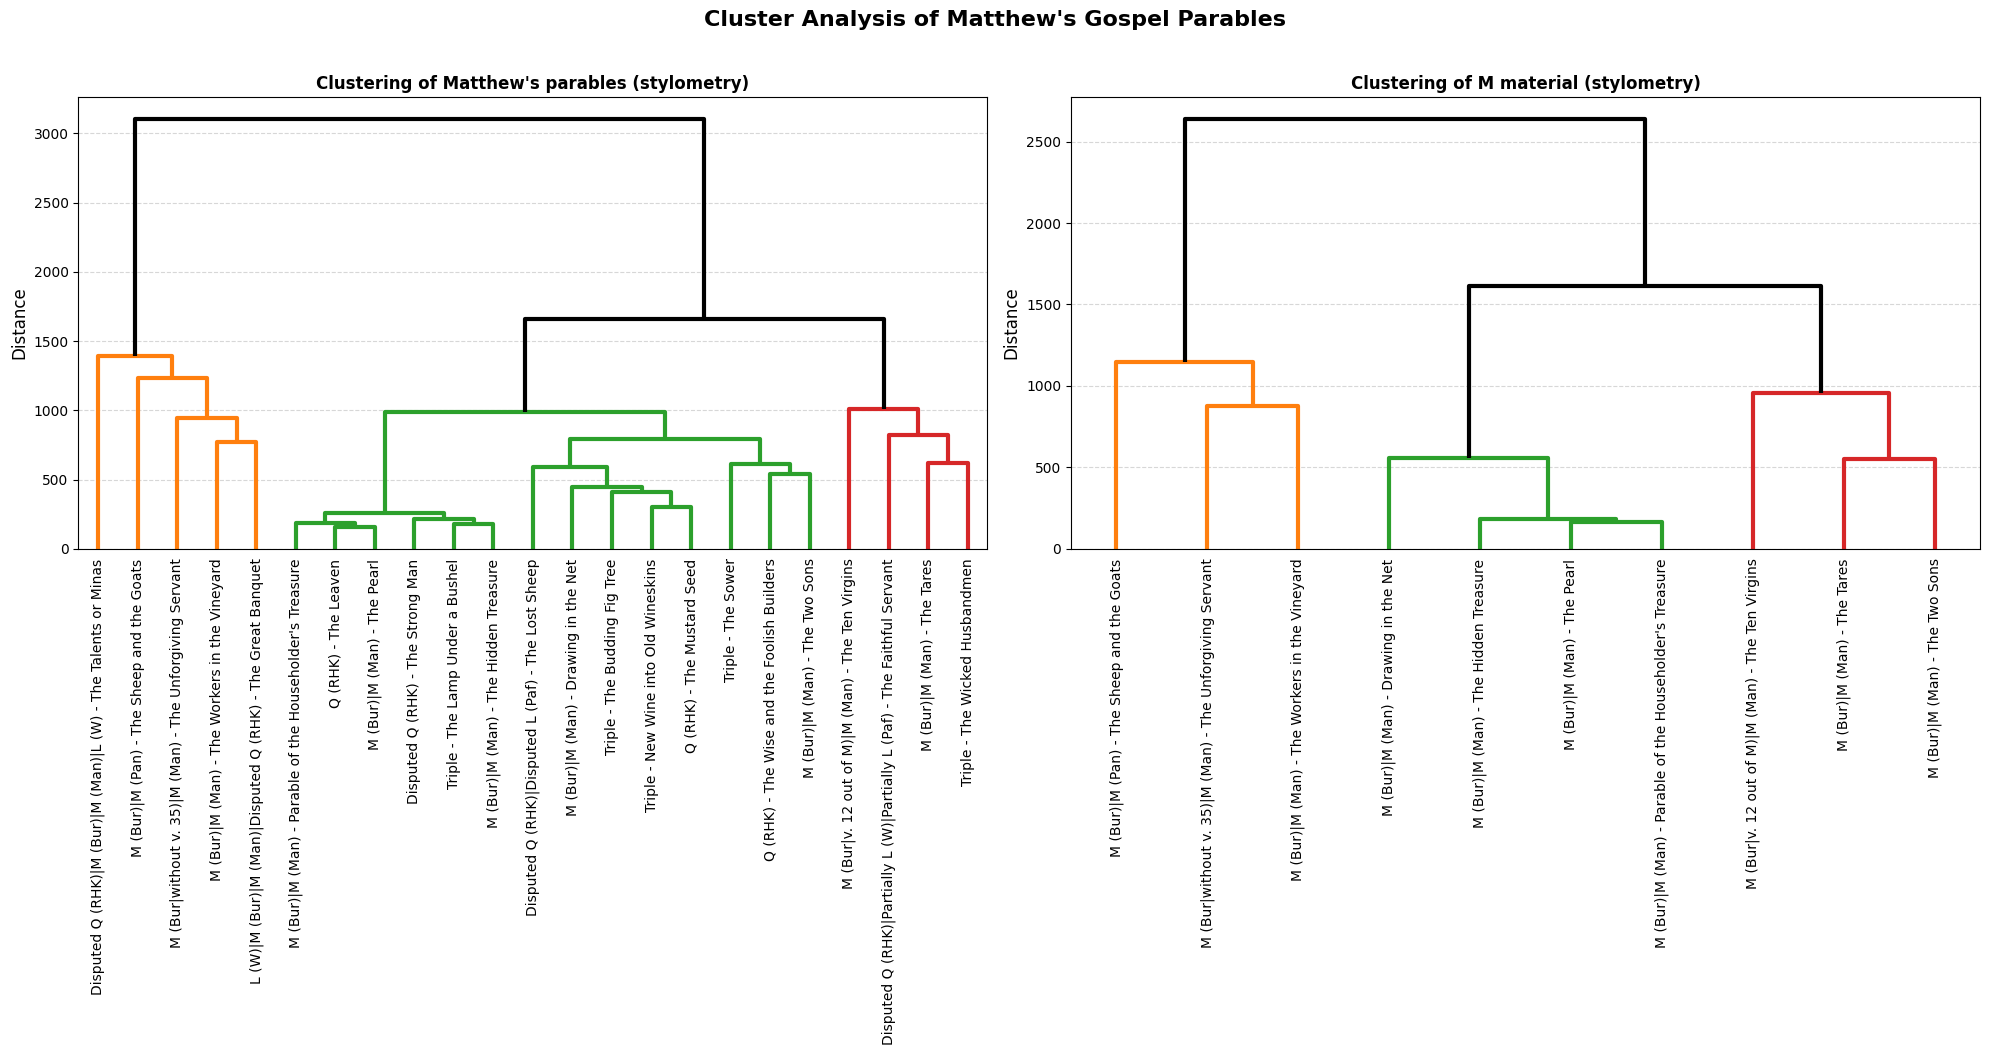

In [512]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering

# Your stylometry_df should be defined already

# Set up the figure with two subplots side by side
fig, ax = plt.subplots(1, 2, figsize=(20, 10))

# First dendrogram (Clustering of Matthew's parables (stylometry))
mt_df = stylometry_df[(stylometry_df["book"] == "Mt")]
pca = umap.UMAP(n_components=10, n_neighbors=5, min_dist=0.1, metric="euclidean", random_state=40)
principal_components = pca.fit_transform(mt_df.drop(columns=["parable", "book", "source", "source_interpretation"]))

# Plot the first dendrogram (now showing "Clustering of Matthew's parables (stylometry)")
plot_dendrogram(
    mt_df.drop(columns=["parable", "book", "source", "source_interpretation"]),
    ax[0],  # Use the first subplot (ax[0])
    labels=[f"{"|".join(source_interpretation.replace("[", "").replace("]", "").replace("'", "").split(", ")[1:])} - {label}" if source_interpretation != "['Triple']" else f"Triple - {label}" for label, source_interpretation in zip(mt_df.parable.values, mt_df.source_interpretation.values)],
    title="Clustering of Matthew's parables (stylometry)",
    linkage_="complete",
    distance_="manhattan",
    leaf_rotation=90,
    leaf_font_size=10,
    color_threshold=1500,
    show_leaf_counts=True,
    annotate_above=0,
    n_clusters=None,
    color_labels=True
)

# Second dendrogram (Clustering of M material)
mt_df = stylometry_df[(stylometry_df["book"] == "Mt") & (stylometry_df["source"] == "M")]
pca = umap.UMAP(n_components=5, n_neighbors=5, min_dist=0.1, metric="euclidean", random_state=40)
principal_components = pca.fit_transform(mt_df.drop(columns=["parable", "book", "source", "source_interpretation"]))

# Plot the second dendrogram (now showing "Clustering of M material")
plot_dendrogram(
    mt_df.drop(columns=["parable", "book", "source", "source_interpretation"]),
    ax[1],  # Use the second subplot (ax[1])
    labels=[f"{"|".join(source_interpretation.replace("[", "").replace("]", "").replace("'", "").split(", ")[1:])} - {label}" if source_interpretation != "['Triple']" else f"Triple - {label}" for label, source_interpretation in zip(mt_df.parable.values, mt_df.source_interpretation.values)],
    title="Clustering of M material (stylometry)",
    linkage_="complete",
    distance_="manhattan",
    leaf_rotation=90,
    leaf_font_size=10,
    color_threshold=1500
,
    show_leaf_counts=True,
    annotate_above=0,
    n_clusters=None,
    color_labels=True
)

plt.tight_layout()  # Adjust layout for better spacing
plt.suptitle("Cluster Analysis of Matthew's Gospel Parables", fontweight='bold', fontsize=16, y=1.05)

plt.savefig("figures/mt_stylometry_dendrograms.png", dpi=1000)
plt.show()



/var/folders/7k/nf094zsx3c3fvbzcnlq9dn000000gn/T/ipykernel_18032/3072685018.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mt_df["cluster"] = hac.fit_predict(mt_df.drop(columns=["parable", "book", "source", "source_interpretation"]))
/Users/sophrobhayek/Documents/dev/auto_q/venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/sophrobhayek/Documents/dev/auto_q/venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/var/folders/7k/nf094zsx3c3fvbzcnlq9dn000000gn/T/ipykernel_18032/3072685018.py:85: Us

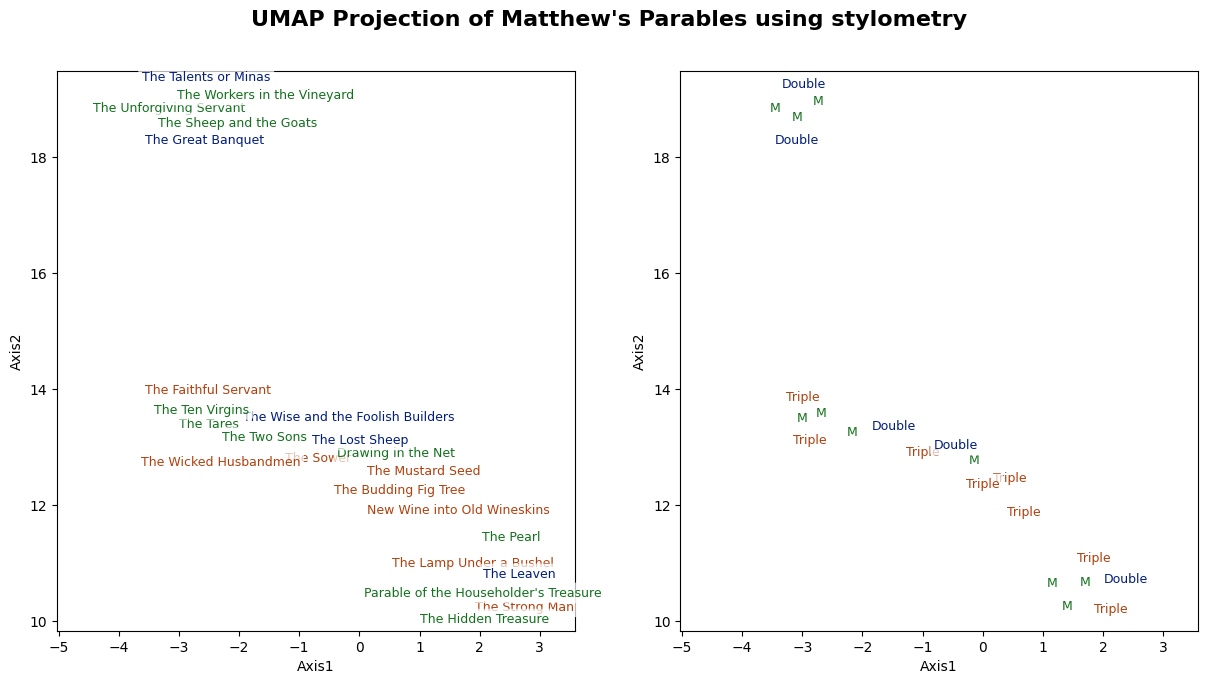

In [513]:
# Perform PCA on the vocabulary matrix
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering
from adjustText import adjust_text
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.spatial import ConvexHull

# Create side-by-side subplots
fig, axes = plt.subplots(1, 2, figsize=(15, 8), constrained_layout=True)  # One row, two columns

# Apply PCA
pca = umap.UMAP(n_components=2, n_neighbors=5, min_dist=0.1, metric="euclidean", random_state=42)
mt_df = stylometry_df[stylometry_df["book"] == "Mt"]

# Apply HAC clustering
selected_number_clusters = find_best_n_clusters(
    mt_df.drop(columns=["parable", "book", "source", "source_interpretation"]),
    min_clusters=2,
    max_clusters=20, 
    metric='cosine', 
    linkage='average'
)
hac = AgglomerativeClustering(n_clusters=selected_number_clusters, linkage='average', metric='cosine')
mt_df["cluster"] = hac.fit_predict(mt_df.drop(columns=["parable", "book", "source", "source_interpretation"]))

# Perform PCA transformation
principal_components = pca.fit_transform(mt_df.drop(columns=["parable", "book", "source", "source_interpretation"]))
principal_df = pd.DataFrame(data=principal_components, columns=["Axis1", "Axis2"])
principal_df["parable"] = mt_df["parable"].values
principal_df["labels"] = mt_df["cluster"].values
principal_df["source"] = mt_df["source"].values  # Only used for the second plot

# Generate a color palette
unique_labels = mt_df["source"].unique()
palette = dict(zip(unique_labels, sns.color_palette("dark", len(unique_labels))))

# Compute Convex Hull to estimate good label boundaries
hull = ConvexHull(principal_df[["Axis1", "Axis2"]].values)
hull_padding = 1.5

# Adjust axis limits based on the convex hull
x_min, x_max = principal_df["Axis1"].min() - hull_padding, principal_df["Axis1"].max() + hull_padding
y_min, y_max = principal_df["Axis2"].min() - 0.2 * hull_padding, principal_df["Axis2"].max() + 0.2 * hull_padding

# ----------- First plot (labels = parables) -----------
ax = axes[0]
# Change alpha to 1 so that points are visible
sns.scatterplot(data=principal_df, x="Axis1", y="Axis2", hue="source", palette=palette, legend=False, alpha=0, ax=ax)
texts = []
for line in range(principal_df.shape[0]):
    texts.append(ax.text(principal_df.Axis1[line], principal_df.Axis2[line],
                         principal_df.parable[line], horizontalalignment='left',
                         size=9, 
                         color=palette[principal_df.source[line]],
                         bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.3')))
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
ax.set_title("", fontweight='bold')
ax.set_xlabel("Axis1")
ax.set_ylabel("Axis2")
adjust_text(texts, expand_text=(1.5, 1.5), expand_points=(2, 2), force_text=(0.2, 0.8), ax=ax)

# ----------- Second plot (labels = sources) -----------
ax = axes[1]
# Change alpha to 1 so that points are visible
p1 = sns.scatterplot(data=principal_df, x="Axis1", y="Axis2", hue="source", palette=palette, legend=False, alpha=0, ax=ax)
texts = []
for line in range(principal_df.shape[0]):
    texts.append(p1.text(principal_df.Axis1[line], principal_df.Axis2[line],
                         principal_df.source[line], horizontalalignment='left',
                         size=9, 
                         color=palette[principal_df.source[line]],
                         bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.3')))
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
ax.set_title("", fontweight='bold')
ax.set_xlabel("Axis1")
ax.set_ylabel("Axis2")
adjust_text(texts, expand_text=(1.5, 1.5), expand_points=(2, 2), force_text=(0.2, 0.1))

# Save and show the figure
plt.suptitle(f"UMAP Projection of Matthew's Parables using stylometry", fontweight='bold', fontsize=16, y=.9)
plt.tight_layout()

plt.savefig("figures/mt_stylometry_pca_side_by_side.png", dpi=600)

plt.show()



In [514]:
mt_df = stylometry_df[(stylometry_df["book"] == "Mt")]

selected_number_clusters = find_best_n_clusters(
    mt_df.drop(columns=["parable", "book", "source", "source_interpretation"]),
    min_clusters=2, max_clusters=20, metric='euclidean', linkage='average')

hac = AgglomerativeClustering(n_clusters=selected_number_clusters, linkage='complete', metric='manhattan')
hac.fit(mt_df.drop(columns=["parable", "book", "source", "source_interpretation"]))
mt_df["cluster"] = hac.labels_

print(mt_df.sort_values(by="cluster")[["cluster", "parable", "source", "source_interpretation"]].to_latex(index=False))

\begin{tabular}{rlll}
\toprule
cluster & parable & source & source_interpretation \\
\midrule
0 & The Wise and the Foolish Builders & Double & ['Double', 'Q (RHK)'] \\
0 & The Ten Virgins & M & ['M', 'M (Bur, v. 12 out of M)', 'M (Man)'] \\
0 & The Faithful Servant & Triple & ['Triple', 'Disputed Q (RHK)', 'Partially L (W)', 'Partially L (Paf)'] \\
0 & The Budding Fig Tree & Triple & ['Triple'] \\
0 & The Wicked Husbandmen & Triple & ['Triple'] \\
0 & The Two Sons & M & ['M', 'M (Bur)', 'M (Man)'] \\
0 & The Lost Sheep & Double & ['Double', 'Disputed Q (RHK)', 'Disputed L (Paf)'] \\
0 & Drawing in the Net & M & ['M', 'M (Bur)', 'M (Man)'] \\
0 & The Pearl & M & ['M', 'M (Bur)', 'M (Man)'] \\
0 & Parable of the Householder's Treasure & M & ['M', 'M (Bur)', 'M (Man)'] \\
0 & The Leaven & Double & ['Double', 'Q (RHK)'] \\
0 & The Mustard Seed & Triple & ['Triple', 'Q (RHK)'] \\
0 & The Tares & M & ['M', 'M (Bur)', 'M (Man)'] \\
0 & The Lamp Under a Bushel & Triple & ['Triple'] \\
0 & The 

/var/folders/7k/nf094zsx3c3fvbzcnlq9dn000000gn/T/ipykernel_18032/3458901641.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mt_df["cluster"] = hac.labels_


In [515]:
mt_df = stylometry_df[(stylometry_df["book"] == "Mt")]

pca = PCA(n_components=12)
principal_components = pca.fit_transform(mt_df.drop(columns=["parable", "book", "source", "source_interpretation"]))

selected_number_clusters = find_best_n_clusters(
    principal_components,
    min_clusters=2, max_clusters=20, metric='manhattan', linkage='complete')

hac = AgglomerativeClustering(n_clusters=3, linkage='complete', metric='manhattan')
hac.fit(principal_components)
mt_df["cluster"] = hac.labels_

print(((mt_df.groupby(["cluster","source"]).count()["parable"]/mt_df.groupby(["cluster"]).count()["parable"])*100).to_latex())
      
      

\begin{tabular}{llr}
\toprule
 &  & parable \\
cluster & source &  \\
\midrule
\multirow[t]{2}{*}{0} & Double & 40.000000 \\
 & M & 60.000000 \\
\cline{1-3}
\multirow[t]{2}{*}{1} & M & 33.333333 \\
 & Triple & 66.666667 \\
\cline{1-3}
\multirow[t]{3}{*}{2} & Double & 20.000000 \\
 & M & 40.000000 \\
 & Triple & 40.000000 \\
\cline{1-3}
\bottomrule
\end{tabular}



/var/folders/7k/nf094zsx3c3fvbzcnlq9dn000000gn/T/ipykernel_18032/3611723602.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mt_df["cluster"] = hac.labels_


## Study Luke

### Vocabulary

/Users/sophrobhayek/Documents/dev/auto_q/venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/sophrobhayek/Documents/dev/auto_q/venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


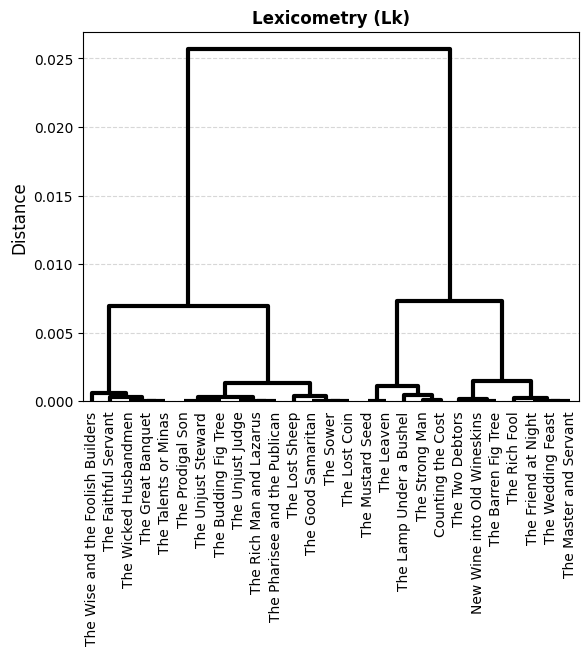

In [516]:
# Mat.Vocab.1 : Apply HAC to the vocabulary dataset of all of Matthew’s parables
pca = umap.UMAP(n_components=2, metric="cosine", n_neighbors=3, random_state=42)
lk_df = frequency_df[frequency_df["book"] == "Lk"]
lk_df = pca.fit_transform(lk_df.drop(columns=["parable", "book", "source", "source_interpretation"]))
lk_df = pd.DataFrame(data=lk_df, columns=["Axis1", "Axis2"])
lk_df["parable"] = frequency_df[frequency_df["book"] == "Lk"]["parable"].values
lk_df["book"] = frequency_df[frequency_df["book"] == "Lk"]["book"].values
lk_df["source"] = frequency_df[frequency_df["book"] == "Lk"]["source"].values
lk_df["source_interpretation"] = frequency_df[frequency_df["book"] == "Lk"]["source_interpretation"].values


plot_dendrogram(
    lk_df.drop(columns=["parable",
                               "book",
                               "source",
                               "source_interpretation"]),
    plt.gca(),
    #labels=luke_df["parable"].values,
    labels=lk_df.parable.values,
    title="Lexicometry (Lk)",
    linkage_="average",
    distance_="cosine",
    figsize=(10, 6),
    leaf_rotation=90,
    leaf_font_size=10,
    color_threshold=0,
    show_leaf_counts=True,
    annotate_above=0,
    n_clusters=None,
    color_labels=True
)

selected_number_clusters = find_best_n_clusters(lk_df.drop(columns=["parable",
                               "book",
                               "source",
                               "source_interpretation"]), min_clusters=2, max_clusters=20, metric='cosine', linkage='average')

hac = AgglomerativeClustering(n_clusters=selected_number_clusters, linkage='average', metric='cosine')
hac.fit(lk_df.drop(columns=["parable",
                            "book",
                            "source",
                            "source_interpretation"]))
lk_df["cluster"] = hac.labels_

/var/folders/7k/nf094zsx3c3fvbzcnlq9dn000000gn/T/ipykernel_18032/2167863327.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mt_df["cluster"] = hac.fit_predict(mt_df.drop(columns=["parable", "book", "source", "source_interpretation"]))
/Users/sophrobhayek/Documents/dev/auto_q/venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/sophrobhayek/Documents/dev/auto_q/venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/var/folders/7k/nf094zsx3c3fvbzcnlq9dn000000gn/T/ipykernel_18032/2167863327.py:85: Us

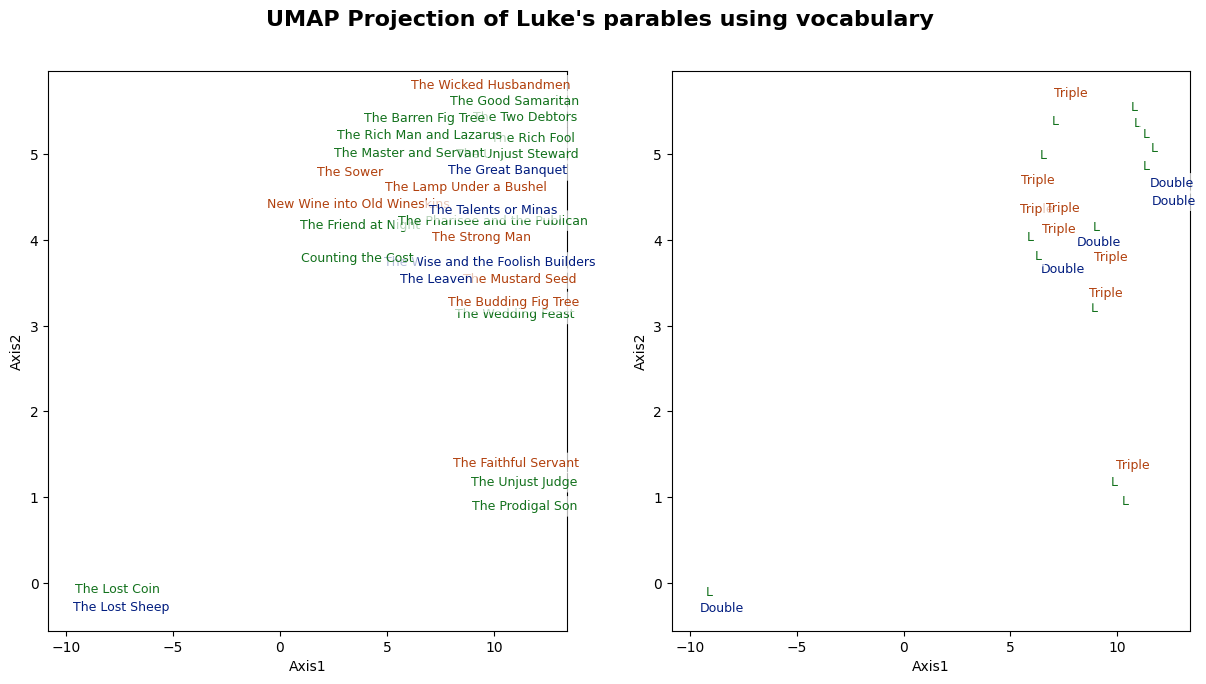

In [517]:
# Perform PCA on the vocabulary matrix
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering
from adjustText import adjust_text
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.spatial import ConvexHull

# Create side-by-side subplots
fig, axes = plt.subplots(1, 2, figsize=(15, 8), constrained_layout=True)  # One row, two columns

# Apply PCA
pca = umap.UMAP(n_components=2, n_neighbors=2, min_dist=0.1, metric="euclidean", random_state=42)
mt_df = frequency_df[frequency_df["book"] == "Lk"]

# Apply HAC clustering
selected_number_clusters = find_best_n_clusters(
    mt_df.drop(columns=["parable", "book", "source", "source_interpretation"]),
    min_clusters=2,
    max_clusters=20, 
    metric='cosine', 
    linkage='average'
)
hac = AgglomerativeClustering(n_clusters=selected_number_clusters, linkage='average', metric='cosine')
mt_df["cluster"] = hac.fit_predict(mt_df.drop(columns=["parable", "book", "source", "source_interpretation"]))

# Perform PCA transformation
principal_components = pca.fit_transform(mt_df.drop(columns=["parable", "book", "source", "source_interpretation"]))
principal_df = pd.DataFrame(data=principal_components, columns=["Axis1", "Axis2"])
principal_df["parable"] = mt_df["parable"].values
principal_df["labels"] = mt_df["cluster"].values
principal_df["source"] = mt_df["source"].values  # Only used for the second plot

# Generate a color palette
unique_labels = mt_df["source"].unique()
palette = dict(zip(unique_labels, sns.color_palette("dark", len(unique_labels))))

# Compute Convex Hull to estimate good label boundaries
hull = ConvexHull(principal_df[["Axis1", "Axis2"]].values)
hull_padding = 1.5

# Adjust axis limits based on the convex hull
x_min, x_max = principal_df["Axis1"].min() - hull_padding, principal_df["Axis1"].max() + hull_padding
y_min, y_max = principal_df["Axis2"].min() - 0.2 * hull_padding, principal_df["Axis2"].max() + 0.2 * hull_padding

# ----------- First plot (labels = parables) -----------
ax = axes[0]
# Change alpha to 1 so that points are visible
sns.scatterplot(data=principal_df, x="Axis1", y="Axis2", hue="source", palette=palette, legend=False, alpha=0, ax=ax)
texts = []
for line in range(principal_df.shape[0]):
    texts.append(ax.text(principal_df.Axis1[line], principal_df.Axis2[line],
                         principal_df.parable[line], horizontalalignment='left',
                         size=9, 
                         color=palette[principal_df.source[line]],
                         bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.3')))
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
ax.set_title("", fontweight='bold')
ax.set_xlabel("Axis1")
ax.set_ylabel("Axis2")
adjust_text(texts, expand_text=(1.5, 1.5), expand_points=(2, 2), force_text=(0.2, 0.8), ax=ax)

# ----------- Second plot (labels = sources) -----------
ax = axes[1]
# Change alpha to 1 so that points are visible
p1 = sns.scatterplot(data=principal_df, x="Axis1", y="Axis2", hue="source", palette=palette, legend=False, alpha=0, ax=ax)
texts = []
for line in range(principal_df.shape[0]):
    texts.append(p1.text(principal_df.Axis1[line], principal_df.Axis2[line],
                         principal_df.source[line], horizontalalignment='left',
                         size=9,
                         color=palette[principal_df.source[line]],
                         bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.3')))
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
ax.set_title("", fontweight='bold')
ax.set_xlabel("Axis1")
ax.set_ylabel("Axis2")
adjust_text(texts, expand_text=(1.5, 1.5), expand_points=(2, 2), force_text=(0.2, 0.1))

# Save and show the figure
plt.suptitle(f"UMAP Projection of Luke's parables using vocabulary", fontweight='bold', fontsize=16, y=.9)
plt.tight_layout()

plt.savefig("figures/lk_vocabulary_pca_side_by_side.png", dpi=600)

plt.show()


/Users/sophrobhayek/Documents/dev/auto_q/venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/sophrobhayek/Documents/dev/auto_q/venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/sophrobhayek/Documents/dev/auto_q/venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/var/folders/7k/nf094zsx3c3fvbzcnlq9dn000000gn/T/ipykernel_18032/4173386154.py:91: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


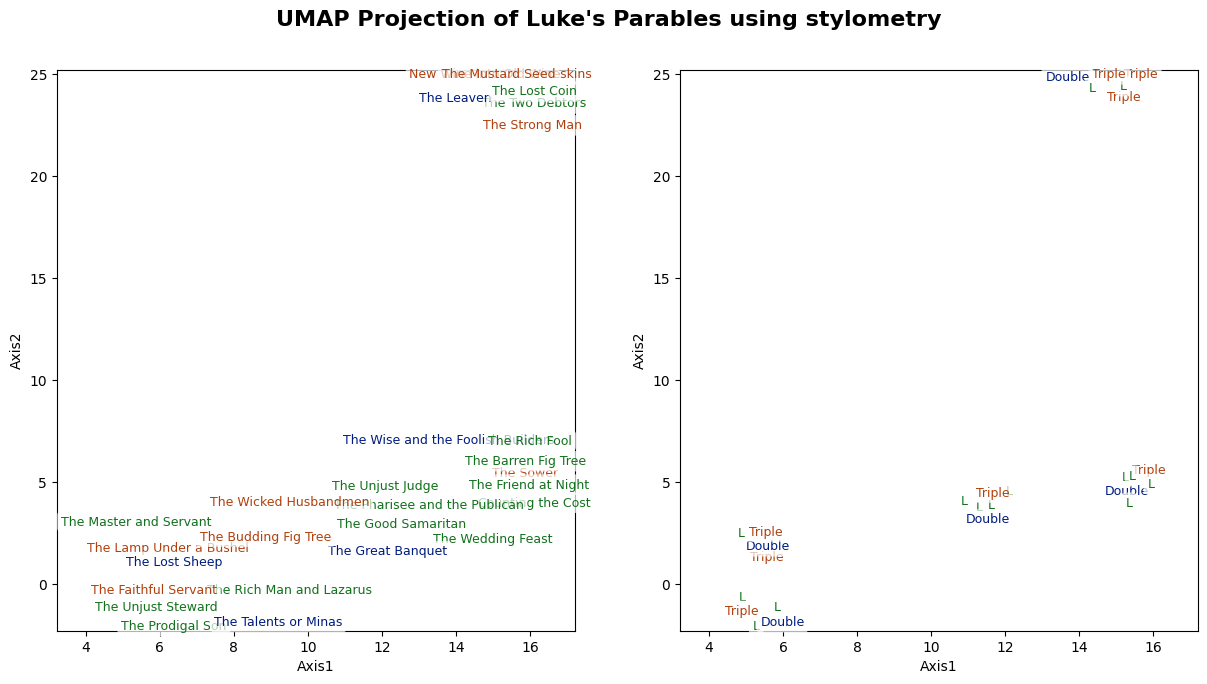

In [518]:
# Perform PCA on the vocabulary matrix
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering
from adjustText import adjust_text
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.spatial import ConvexHull

# Create side-by-side subplots
fig, axes = plt.subplots(1, 2, figsize=(15, 8), constrained_layout=True)  # One row, two columns

# Apply PCA
pca = umap.UMAP(n_components=2, n_neighbors=5, min_dist=0.1, metric="euclidean", random_state=42)
mt_df = stylometry_df[stylometry_df["book"] == "Lk"]
mt_df = pca.fit_transform(mt_df.drop(columns=["parable", "book", "source", "source_interpretation"]))
mt_df = pd.DataFrame(data=mt_df, columns=["Axis1", "Axis2"])
mt_df["parable"] = stylometry_df[stylometry_df["book"] == "Lk"]["parable"].values
mt_df["book"] = stylometry_df[stylometry_df["book"] == "Lk"]["book"].values
mt_df["source"] = stylometry_df[stylometry_df["book"] == "Lk"]["source"].values
mt_df["source_interpretation"] = stylometry_df[stylometry_df["book"] == "Lk"]["source_interpretation"].values

# Apply HAC clustering
selected_number_clusters = find_best_n_clusters(
    mt_df.drop(columns=["parable", "book", "source", "source_interpretation"]),
    min_clusters=2,
    max_clusters=20, 
    metric='cosine', 
    linkage='average'
)
hac = AgglomerativeClustering(n_clusters=selected_number_clusters, linkage='average', metric='cosine')
mt_df["cluster"] = hac.fit_predict(mt_df.drop(columns=["parable", "book", "source", "source_interpretation"]))

# Perform PCA transformation
principal_components = pca.fit_transform(mt_df.drop(columns=["parable", "book", "source", "source_interpretation"]))
principal_df = pd.DataFrame(data=principal_components, columns=["Axis1", "Axis2"])
principal_df["parable"] = mt_df["parable"].values
principal_df["labels"] = mt_df["cluster"].values
principal_df["source"] = mt_df["source"].values  # Only used for the second plot

# Generate a color palette
unique_labels = mt_df["source"].unique()
palette = dict(zip(unique_labels, sns.color_palette("dark", len(unique_labels))))

# Compute Convex Hull to estimate good label boundaries
hull = ConvexHull(principal_df[["Axis1", "Axis2"]].values)
hull_padding = 1.5

# Adjust axis limits based on the convex hull
x_min, x_max = principal_df["Axis1"].min() - hull_padding, principal_df["Axis1"].max() + hull_padding
y_min, y_max = principal_df["Axis2"].min() - 0.2 * hull_padding, principal_df["Axis2"].max() + 0.2 * hull_padding

# ----------- First plot (labels = parables) -----------
ax = axes[0]
# Change alpha to 1 so that points are visible
sns.scatterplot(data=principal_df, x="Axis1", y="Axis2", hue="source", palette=palette, legend=False, alpha=0, ax=ax)
texts = []
for line in range(principal_df.shape[0]):
    texts.append(ax.text(principal_df.Axis1[line], principal_df.Axis2[line],
                         principal_df.parable[line], horizontalalignment='left',
                         size=9,
                         color=palette[principal_df.source[line]],
                         bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.3')))
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
ax.set_title("", fontweight='bold')
ax.set_xlabel("Axis1")
ax.set_ylabel("Axis2")
adjust_text(texts, expand_text=(1.5, 1.5), expand_points=(2, 2), force_text=(0.2, 0.8), ax=ax)

# ----------- Second plot (labels = sources) -----------
ax = axes[1]
# Change alpha to 1 so that points are visible
p1 = sns.scatterplot(data=principal_df, x="Axis1", y="Axis2", hue="source", palette=palette, legend=False, alpha=0, ax=ax)
texts = []
for line in range(principal_df.shape[0]):
    texts.append(p1.text(principal_df.Axis1[line], principal_df.Axis2[line],
                         principal_df.source[line], horizontalalignment='left',
                         size=9,
                         color=palette[principal_df.source[line]],
                         bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.3')))
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
ax.set_title("", fontweight='bold')
ax.set_xlabel("Axis1")
ax.set_ylabel("Axis2")
adjust_text(texts, expand_text=(1.5, 1.5), expand_points=(2, 2), force_text=(0.2, 0.1))

# Save and show the figure
plt.suptitle(f"UMAP Projection of Luke's Parables using stylometry", fontweight='bold', fontsize=16, y=.9)
plt.tight_layout()

plt.savefig("figures/lk_stylometry_pca_side_by_side.png", dpi=600)

plt.show()



/Users/sophrobhayek/Documents/dev/auto_q/venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/sophrobhayek/Documents/dev/auto_q/venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/sophrobhayek/Documents/dev/auto_q/venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/sophrobhayek/Documents/dev/auto_q/venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


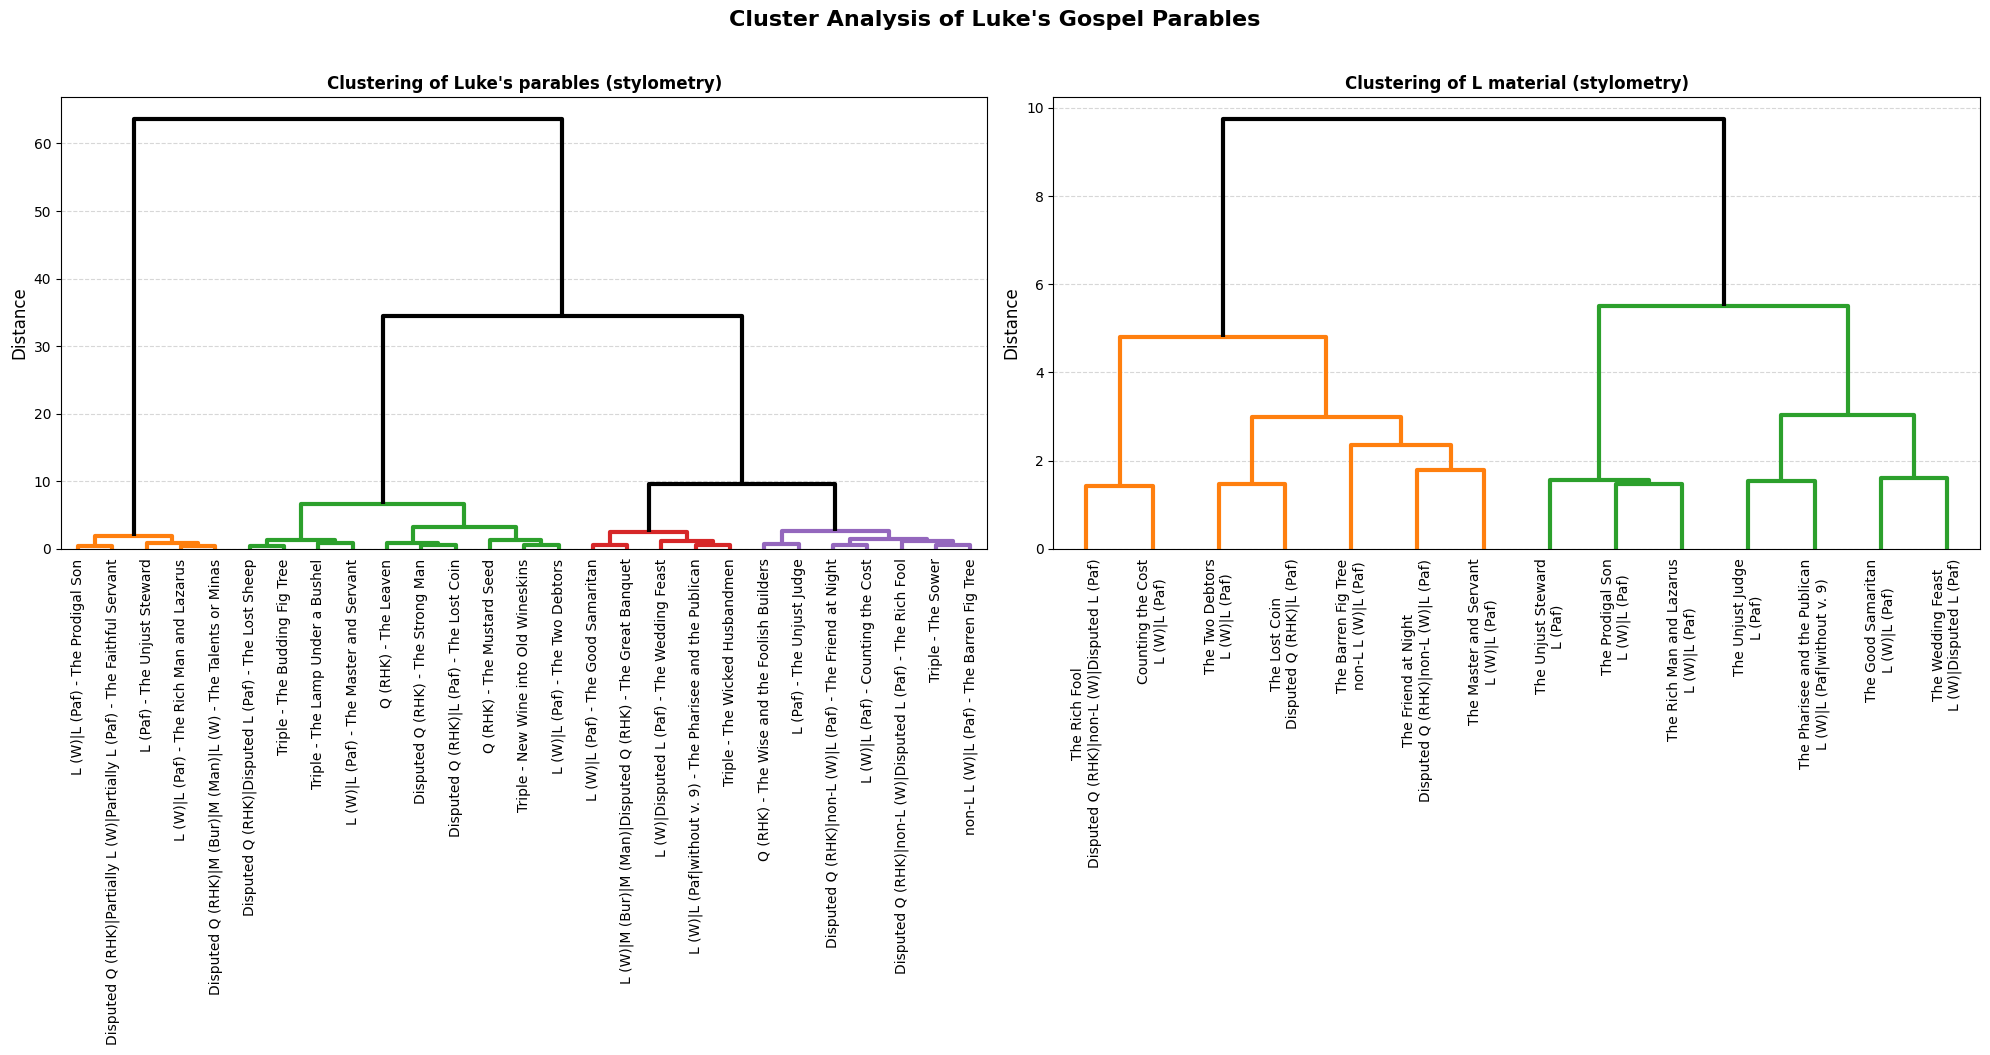

In [519]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering

# Your stylometry_df should be defined already

# Set up the figure with two subplots side by side
fig, ax = plt.subplots(1, 2, figsize=(20, 10))

# First dendrogram (Clustering of Matthew's parables (stylometry))
lk_df = stylometry_df[(stylometry_df["book"] == "Lk")]
pca = umap.UMAP(n_components=5, n_neighbors=3, min_dist=0.1, metric="euclidean", random_state=42)
principal_components = pca.fit_transform(lk_df.drop(columns=["parable", "book", "source", "source_interpretation"]))

# Plot the first dendrogram (now showing "Clustering of Matthew's parables (stylometry)")
plot_dendrogram(
    principal_components,
    ax[0],  # Use the first subplot (ax[0])
    labels=[f"{"|".join(source_interpretation.replace("[", "").replace("]", "").replace("'", "").split(", ")[1:])} - {label}" if source_interpretation != "['Triple']" else f"Triple - {label}" for label, source_interpretation in zip(lk_df.parable.values, lk_df.source_interpretation.values)],
    title="Clustering of Luke's parables (stylometry)",
    linkage_="complete",
    distance_="manhattan",
    leaf_rotation=90,
    leaf_font_size=10,
    color_threshold=9,
    show_leaf_counts=True,
    annotate_above=0,
    n_clusters=None,
    color_labels=True
)

# Second dendrogram (Clustering of M material)
lk_df = stylometry_df[(stylometry_df["book"] == "Lk") & (stylometry_df["source"] == "L")]
pca = umap.UMAP(n_components=10, n_neighbors=5, min_dist=0.1, metric="euclidean", random_state=42)
principal_components = pca.fit_transform(lk_df.drop(columns=["parable", "book", "source", "source_interpretation"]))

# Plot the second dendrogram (now showing "Clustering of M material")
plot_dendrogram(
    principal_components,
    ax[1],  # Use the second subplot (ax[1])
    labels=[f"{label}\n{"|".join(source_interpretation.replace("[", "").replace("]", "").replace("'", "").split(", ")[1:])}" if source_interpretation != "['Triple']" else f"Triple - {label}" for label, source_interpretation in zip(lk_df.parable.values, lk_df.source_interpretation.values)],
    title="Clustering of L material (stylometry)",
    linkage_="complete",
    distance_="manhattan",
    leaf_rotation=90,
    leaf_font_size=10,
    color_threshold=8,
    show_leaf_counts=True,
    annotate_above=0,
    n_clusters=None,
    color_labels=True
)

plt.tight_layout()  # Adjust layout for better spacing
plt.suptitle("Cluster Analysis of Luke's Gospel Parables", fontweight='bold', fontsize=16, y=1.05)

plt.savefig("figures/lk_stylometry_dendrograms.png", dpi=600)
plt.show()



In [520]:
lk_df = stylometry_df[(stylometry_df["book"] == "Lk")]

pca = PCA(n_components=12)
principal_components = pca.fit_transform(lk_df.drop(columns=["parable", "book", "source", "source_interpretation"]))

selected_number_clusters = find_best_n_clusters(
    principal_components,
    min_clusters=2, max_clusters=20, metric='manhattan', linkage='complete')

hac = AgglomerativeClustering(n_clusters=3, linkage='complete', metric='manhattan')
hac.fit(principal_components)
lk_df["cluster"] = hac.labels_

print(lk_df.sort_values(by="cluster")[["cluster", "parable", "source_interpretation"]].to_latex(index=False))

\begin{tabular}{rll}
\toprule
cluster & parable & source_interpretation \\
\midrule
0 & The Wise and the Foolish Builders & ['Double', 'Q (RHK)'] \\
0 & The Budding Fig Tree & ['Triple'] \\
0 & The Great Banquet & ['Double', 'L (W)', 'M (Bur)', 'M (Man)', 'Disputed Q (RHK)'] \\
0 & The Wicked Husbandmen & ['Triple'] \\
0 & The Pharisee and the Publican & ['L', 'L (W)', 'L (Paf, without v. 9)'] \\
0 & The Unjust Judge & ['L', 'L (Paf)'] \\
0 & The Master and Servant & ['L', 'L (W)', 'L (Paf)'] \\
0 & The Lost Coin & ['L', 'Disputed Q (RHK)', 'L (Paf)'] \\
0 & The Lost Sheep & ['Double', 'Disputed Q (RHK)', 'Disputed L (Paf)'] \\
0 & The Wedding Feast & ['L', 'L (W)', 'Disputed L (Paf)'] \\
0 & The Leaven & ['Double', 'Q (RHK)'] \\
0 & Counting the Cost & ['L', 'L (W)', 'L (Paf)'] \\
0 & The Barren Fig Tree & ['L', 'non-L L (W)', 'L (Paf)'] \\
0 & The Rich Fool & ['L', 'Disputed Q (RHK)', 'non-L (W)', 'Disputed L (Paf)'] \\
0 & The Friend at Night & ['L', 'Disputed Q (RHK)', 'non-L (W)',

/var/folders/7k/nf094zsx3c3fvbzcnlq9dn000000gn/T/ipykernel_18032/3051464408.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  lk_df["cluster"] = hac.labels_


In [521]:
lk_df = stylometry_df[(stylometry_df["book"] == "Lk")]

pca = PCA(n_components=12)
principal_components = pca.fit_transform(lk_df.drop(columns=["parable", "book", "source", "source_interpretation"]))

selected_number_clusters = find_best_n_clusters(
    principal_components,
    min_clusters=2, max_clusters=20, metric='manhattan', linkage='complete')

hac = AgglomerativeClustering(n_clusters=4, linkage='complete', metric='manhattan')
hac.fit(principal_components)
lk_df["cluster"] = hac.labels_

print(((lk_df.groupby(["cluster","source"]).count()["parable"]/lk_df.groupby(["cluster"]).count()["parable"])*100).to_latex())
      
      

\begin{tabular}{llr}
\toprule
 &  & parable \\
cluster & source &  \\
\midrule
\multirow[t]{3}{*}{0} & Double & 18.181818 \\
 & L & 72.727273 \\
 & Triple & 9.090909 \\
\cline{1-3}
\multirow[t]{3}{*}{1} & Double & 25.000000 \\
 & L & 50.000000 \\
 & Triple & 25.000000 \\
\cline{1-3}
2 & L & 100.000000 \\
\cline{1-3}
\multirow[t]{3}{*}{3} & Double & 18.181818 \\
 & L & 27.272727 \\
 & Triple & 54.545455 \\
\cline{1-3}
\bottomrule
\end{tabular}



/var/folders/7k/nf094zsx3c3fvbzcnlq9dn000000gn/T/ipykernel_18032/34743592.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  lk_df["cluster"] = hac.labels_


In [522]:
lk_df.groupby(["cluster","source"]).count()

parable  book  source_interpretation  pos_A  pos_C  pos_RR  \
cluster source                                                               
0       Double        2     2                      2      2      2       2   
        L             8     8                      8      8      8       8   
        Triple        1     1                      1      1      1       1   
1       Double        1     1                      1      1      1       1   
        L             2     2                      2      2      2       2   
        Triple        1     1                      1      1      1       1   
2       L             1     1                      1      1      1       1   
3       Double        2     2                      2      2      2       2   
        L             3     3                      3      3      3       3   
        Triple        6     6                      6      6      6       6   

                pos_V  pos_RP  pos_RA  pos_N  ...  pos_RR_RD  pos_RD_RR  \
cluster source                                ...                         
0       Double      2       2       2      2  ...          2          2   
        L           8       8       8      8  ...          8          8   
        Triple      1       1       1      1  ...          1          1   
1       Double      1       1       1      1  ...          1          1   
        L           2       2       2      2  ...          2          2   
        Triple      1       1       1      1  ...          1          1   
2       L           1       1       1      1  ...          1          1   
3       Double      2       2       2      2  ...          2          2   
        L           3       3       3      3  ...          3          3   
        Triple      6       6       6      6  ...          6          6   

                pos_RD_RD  pos_RA_RA  tense_I_F  pos_P_V  pos_X_RP  tense_Y_A  \
cluster source                                                                  
0       Double          2          2          2        2         2          2   
        L               8          8          8        8         8          8   
        Triple          1          1          1        1         1          1   
1       Double          1          1          1        1         1          1   
        L               2          2          2        2         2          2   
        Triple          1          1          1        1         1          1   
2       L               1          1          1        1         1          1   
3       Double          2          2          2        2         2          2   
        L               3          3          3        3         3          3   
        Triple          6          6          6        6         6          6   

                tense_F_Y  tense_F_X  
cluster source                        
0       Double          2          2  
        L               8          8  
        Triple          1          1  
1       Double          1          1  
        L               2          2  
        Triple          1          1  
2       L               1          1  
3       Double          2          2  
        L               3          3  
        Triple          6          6  

[10 rows x 398 columns]